## 1. Setup and input files

Set paths, random seed, package metadata, and check that the required CSV files are available.

In [1]:
from pathlib import Path
import os
import json
import random
import platform
import warnings
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Datasets"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

OUT_DIR = BASE_DIR / "output"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
ARTIFACT_DIR = OUT_DIR / "artifacts"

for path in [OUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR, ARTIFACT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)


def package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


packages = {
    "python": platform.python_version(),
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scikit-learn": package_version("scikit-learn"),
    "matplotlib": package_version("matplotlib"),
    "torch": package_version("torch"),
    "xgboost": package_version("xgboost"),
    "lightgbm": package_version("lightgbm"),
    "shap": package_version("shap"),
}

run_info = {
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "base_dir": str(BASE_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUT_DIR),
    "seed": SEED,
    "platform": platform.platform(),
    "torch_available": TORCH_AVAILABLE,
    "packages": packages,
}

with open(OUT_DIR / "run_info.json", "w", encoding="utf-8") as f:
    json.dump(run_info, f, indent=4)

csv_files = {
    "unsw_train": "UNSW_NB15_training-set.csv",
    "unsw_test": "UNSW_NB15_testing-set.csv",
    "ton_iot": "ton-iot-train_test_network.csv",
}

file_paths = {}

for key, file_name in csv_files.items():
    path = DATA_DIR / file_name

    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    file_paths[key] = path

inventory = []

for key, path in file_paths.items():
    preview = pd.read_csv(path, nrows=5)

    inventory.append({
        "dataset": key,
        "file_name": path.name,
        "path": str(path),
        "size_mb": round(path.stat().st_size / (1024 ** 2), 2),
        "n_columns": preview.shape[1],
        "first_columns": list(preview.columns[:12]),
    })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(TABLE_DIR / "dataset_inventory.csv", index=False)

print(f"Base directory : {BASE_DIR}")
print(f"Data directory : {DATA_DIR}")
print(f"Output folder  : {OUT_DIR}")
print(f"Seed           : {SEED}")
print(f"Torch available: {TORCH_AVAILABLE}")

print("\nPackage versions")
for name, pkg_version in packages.items():
    print(f"{name:14s}: {pkg_version}")

print("\nInput files")
display(inventory_df)

Base directory : F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS
Data directory : F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\Datasets
Output folder  : F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output
Seed           : 42
Torch available: True

Package versions
python        : 3.10.20
numpy         : 1.26.4
pandas        : 2.3.3
scikit-learn  : 1.7.2
matplotlib    : 3.10.8
torch         : 2.11.0+cu126
xgboost       : 3.2.0
lightgbm      : 4.6.0
shap          : 0.49.1

Input files


,dataset,file_name,path,size_mb,n_columns,first_columns
0,unsw_train,UNSW_NB15_training-set.csv,F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\Datasets\UNSW_NB15_training-set.csv,30.80,45,"[id, dur, proto, service, state, spkts, dpkts, sbytes, dbytes, rate, sttl, dttl]"
1,unsw_test,UNSW_NB15_testing-set.csv,F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\Datasets\UNSW_NB15_testing-set.csv,14.67,45,"[id, dur, proto, service, state, spkts, dpkts, sbytes, dbytes, rate, sttl, dttl]"
2,ton_iot,ton-iot-train_test_network.csv,F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\Datasets\ton-iot-train_test_network.csv,28.52,44,"[src_ip, src_port, dst_ip, dst_port, proto, service, duration, src_bytes, dst_bytes, conn_state, missed_bytes, src_p..."


## 2. Load data and check schema

Load the raw CSV files and inspect dataset size, column types, missing values, duplicates, label fields, and shared columns.

In [2]:
unsw_train = pd.read_csv(file_paths["unsw_train"])
unsw_test = pd.read_csv(file_paths["unsw_test"])
ton_iot = pd.read_csv(file_paths["ton_iot"])

raw_datasets = {
    "unsw_train": unsw_train,
    "unsw_test": unsw_test,
    "ton_iot": ton_iot,
}


def memory_mb(df):
    return round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2)


def find_label_columns(df):
    keywords = ["label", "attack", "category", "cat", "type", "class", "target"]

    return [
        col for col in df.columns
        if any(key in col.lower() for key in keywords)
    ]


def summarize_dataset(name, df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    return {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "memory_mb": memory_mb(df),
        "numeric_columns": len(numeric_cols),
        "categorical_columns": len(categorical_cols),
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "label_columns": find_label_columns(df),
    }


def profile_columns(name, df):
    rows = []

    for col in df.columns:
        values = df[col].dropna().astype(str).unique()[:5]

        rows.append({
            "dataset": name,
            "column": col,
            "dtype": str(df[col].dtype),
            "missing_count": int(df[col].isna().sum()),
            "missing_percent": round(df[col].isna().mean() * 100, 4),
            "unique_values": int(df[col].nunique(dropna=True)),
            "sample_values": list(values),
        })

    return pd.DataFrame(rows)


def label_counts(name, df):
    rows = []

    for col in find_label_columns(df):
        counts = df[col].value_counts(dropna=False).reset_index()
        counts.columns = ["value", "count"]
        counts["dataset"] = name
        counts["column"] = col
        counts["percent"] = (counts["count"] / len(df) * 100).round(4)

        rows.append(counts[["dataset", "column", "value", "count", "percent"]])

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame(columns=["dataset", "column", "value", "count", "percent"])


dataset_summary = pd.DataFrame([
    summarize_dataset(name, df)
    for name, df in raw_datasets.items()
])

column_profile = pd.concat(
    [profile_columns(name, df) for name, df in raw_datasets.items()],
    ignore_index=True,
)

label_summary = pd.concat(
    [label_counts(name, df) for name, df in raw_datasets.items()],
    ignore_index=True,
)

unsw_cols = set(unsw_train.columns)
ton_cols = set(ton_iot.columns)

overlap = {
    "common_columns": sorted(unsw_cols & ton_cols),
    "unsw_only_columns": sorted(unsw_cols - ton_cols),
    "ton_only_columns": sorted(ton_cols - unsw_cols),
}

column_overlap = pd.DataFrame({
    "group": ["common", "unsw_only", "ton_only"],
    "n_columns": [
        len(overlap["common_columns"]),
        len(overlap["unsw_only_columns"]),
        len(overlap["ton_only_columns"]),
    ],
    "columns": [
        overlap["common_columns"],
        overlap["unsw_only_columns"],
        overlap["ton_only_columns"],
    ],
})

dataset_summary.to_csv(TABLE_DIR / "raw_dataset_summary.csv", index=False)
column_profile.to_csv(TABLE_DIR / "raw_column_profile.csv", index=False)
label_summary.to_csv(TABLE_DIR / "raw_label_counts.csv", index=False)
column_overlap.to_csv(TABLE_DIR / "raw_column_overlap.csv", index=False)

with open(OUT_DIR / "raw_column_overlap.json", "w", encoding="utf-8") as f:
    json.dump(overlap, f, indent=4)

print("Dataset summary")
display(dataset_summary)

print("\nColumn overlap")
display(column_overlap)

print("\nLabel counts")
display(label_summary)

print("\nColumn profile")
display(column_profile.head(30))

Dataset summary


,dataset,rows,columns,memory_mb,numeric_columns,categorical_columns,missing_values,duplicate_rows,label_columns
0,unsw_train,175341,45,95.56,41,4,0,0,"[attack_cat, label]"
1,unsw_test,82332,45,44.84,41,4,0,0,"[attack_cat, label]"
2,ton_iot,211043,44,350.24,17,27,0,20569,"[dns_qclass, dns_qtype, http_orig_mime_types, http_resp_mime_types, label, type]"



Column overlap


,group,n_columns,columns
0,common,3,"[label, proto, service]"
1,unsw_only,42,"[ackdat, attack_cat, ct_dst_ltm, ct_dst_sport_ltm, ct_dst_src_ltm, ct_flw_http_mthd, ct_ftp_cmd, ct_src_dport_ltm, c..."
2,ton_only,41,"[conn_state, dns_AA, dns_RA, dns_RD, dns_qclass, dns_qtype, dns_query, dns_rcode, dns_rejected, dst_bytes, dst_ip, d..."



Label counts


,dataset,column,value,count,percent
0,unsw_train,attack_cat,Normal,56000,31.9378
1,unsw_train,attack_cat,Generic,40000,22.8127
2,unsw_train,attack_cat,Exploits,33393,19.0446
3,unsw_train,attack_cat,Fuzzers,18184,10.3706
4,unsw_train,attack_cat,DoS,12264,6.9944
...,...,...,...,...,...
59,ton_iot,type,password,20000,9.4767
60,ton_iot,type,scanning,20000,9.4767
61,ton_iot,type,ransomware,20000,9.4767
62,ton_iot,type,xss,20000,9.4767



Column profile


,dataset,column,dtype,missing_count,missing_percent,unique_values,sample_values
0,unsw_train,id,int64,0,0.0,175341,"[1, 2, 3, 4, 5]"
1,unsw_train,dur,float64,0,0.0,74039,"[0.121478, 0.649902, 1.623129, 1.681642, 0.449454]"
2,unsw_train,proto,object,0,0.0,133,"[tcp, udp, arp, ospf, icmp]"
3,unsw_train,service,object,0,0.0,13,"[-, ftp, smtp, snmp, http]"
4,unsw_train,state,object,0,0.0,9,"[FIN, INT, CON, ECO, REQ]"
5,unsw_train,spkts,int64,0,0.0,480,"[6, 14, 8, 12, 10]"
6,unsw_train,dpkts,int64,0,0.0,443,"[4, 38, 16, 12, 6]"
7,unsw_train,sbytes,int64,0,0.0,7214,"[258, 734, 364, 628, 534]"
8,unsw_train,dbytes,int64,0,0.0,6660,"[172, 42014, 13186, 770, 268]"
9,unsw_train,rate,float64,0,0.0,76991,"[74.08749, 78.473372, 14.170161, 13.677108, 33.373826]"


## 3. Canonical features

Create binary labels and map UNSW-NB15 and ToN-IoT into a shared flow-level feature set.

In [3]:
def clean_category(series):
    return (
        series.astype(str)
        .str.strip()
        .replace({
            "": "unknown",
            "-": "unknown",
            "nan": "unknown",
            "None": "unknown",
            "NaN": "unknown",
        })
        .fillna("unknown")
    )


def safe_divide(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").fillna(0)
    denominator = pd.to_numeric(denominator, errors="coerce").fillna(0)

    out = np.zeros(len(numerator), dtype=float)
    mask = denominator != 0

    out[mask] = numerator[mask] / denominator[mask]

    return out


def build_unsw_features(df, split_name):
    out = pd.DataFrame(index=df.index)

    out["dataset"] = "UNSW-NB15"
    out["split"] = split_name

    out["duration"] = pd.to_numeric(df["dur"], errors="coerce").fillna(0)
    out["src_pkts"] = pd.to_numeric(df["spkts"], errors="coerce").fillna(0)
    out["dst_pkts"] = pd.to_numeric(df["dpkts"], errors="coerce").fillna(0)
    out["src_bytes"] = pd.to_numeric(df["sbytes"], errors="coerce").fillna(0)
    out["dst_bytes"] = pd.to_numeric(df["dbytes"], errors="coerce").fillna(0)

    out["proto"] = clean_category(df["proto"])
    out["service"] = clean_category(df["service"])
    out["state"] = clean_category(df["state"])

    out["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    out["attack_type"] = clean_category(df["attack_cat"]).str.lower()

    return out.reset_index(drop=True)


def build_ton_features(df, split_name):
    out = pd.DataFrame(index=df.index)

    out["dataset"] = "ToN-IoT"
    out["split"] = split_name

    out["duration"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0)
    out["src_pkts"] = pd.to_numeric(df["src_pkts"], errors="coerce").fillna(0)
    out["dst_pkts"] = pd.to_numeric(df["dst_pkts"], errors="coerce").fillna(0)
    out["src_bytes"] = pd.to_numeric(df["src_bytes"], errors="coerce").fillna(0)
    out["dst_bytes"] = pd.to_numeric(df["dst_bytes"], errors="coerce").fillna(0)

    out["proto"] = clean_category(df["proto"])
    out["service"] = clean_category(df["service"])
    out["state"] = clean_category(df["conn_state"])

    out["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    out["attack_type"] = clean_category(df["type"]).str.lower()

    return out.reset_index(drop=True)


def add_flow_features(df):
    df = df.copy()

    df["total_pkts"] = df["src_pkts"] + df["dst_pkts"]
    df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]

    df["src_bytes_per_pkt"] = safe_divide(df["src_bytes"], df["src_pkts"])
    df["dst_bytes_per_pkt"] = safe_divide(df["dst_bytes"], df["dst_pkts"])

    df["bytes_per_sec"] = safe_divide(df["total_bytes"], df["duration"])
    df["pkts_per_sec"] = safe_divide(df["total_pkts"], df["duration"])

    df["src_to_dst_byte_ratio"] = safe_divide(df["src_bytes"], df["dst_bytes"])
    df["src_to_dst_pkt_ratio"] = safe_divide(df["src_pkts"], df["dst_pkts"])

    df["byte_imbalance"] = safe_divide(
        df["src_bytes"] - df["dst_bytes"],
        df["total_bytes"]
    )

    df["pkt_imbalance"] = safe_divide(
        df["src_pkts"] - df["dst_pkts"],
        df["total_pkts"]
    )

    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)

    return df


ton_duplicate_rows = int(ton_iot.duplicated().sum())
ton_iot_clean = ton_iot.drop_duplicates().reset_index(drop=True)

unsw_train_canon = add_flow_features(build_unsw_features(unsw_train, "train"))
unsw_test_canon = add_flow_features(build_unsw_features(unsw_test, "test"))
ton_canon = add_flow_features(build_ton_features(ton_iot_clean, "full"))

numeric_features = [
    "duration",
    "src_pkts",
    "dst_pkts",
    "src_bytes",
    "dst_bytes",
    "total_pkts",
    "total_bytes",
    "src_bytes_per_pkt",
    "dst_bytes_per_pkt",
    "bytes_per_sec",
    "pkts_per_sec",
    "src_to_dst_byte_ratio",
    "src_to_dst_pkt_ratio",
    "byte_imbalance",
    "pkt_imbalance",
]

categorical_features = ["proto", "service", "state"]
model_features = numeric_features + categorical_features
meta_columns = ["dataset", "split", "attack_type", "label"]


canonical_datasets = {
    "unsw_train": unsw_train_canon,
    "unsw_test": unsw_test_canon,
    "ton_iot": ton_canon,
}

summary_rows = []

for name, df in canonical_datasets.items():
    summary_rows.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "normal": int((df["label"] == 0).sum()),
        "attack": int((df["label"] == 1).sum()),
        "attack_percent": round(df["label"].mean() * 100, 3),
        "missing_values": int(df[model_features + ["label"]].isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    })

canonical_summary = pd.DataFrame(summary_rows)

attack_rows = []

for name, df in canonical_datasets.items():
    counts = df["attack_type"].value_counts().reset_index()
    counts.columns = ["attack_type", "count"]
    counts["dataset"] = name
    counts["percent"] = (counts["count"] / len(df) * 100).round(3)

    attack_rows.append(counts[["dataset", "attack_type", "count", "percent"]])

attack_distribution = pd.concat(attack_rows, ignore_index=True)

feature_info = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "model_features": model_features,
    "target": "label",
    "normal_label": 0,
    "attack_label": 1,
    "ton_raw_duplicates_removed": ton_duplicate_rows,
}

with open(OUT_DIR / "feature_info.json", "w", encoding="utf-8") as f:
    json.dump(feature_info, f, indent=4)

canonical_summary.to_csv(TABLE_DIR / "canonical_summary.csv", index=False)
attack_distribution.to_csv(TABLE_DIR / "attack_distribution.csv", index=False)

unsw_train_canon.to_parquet(OUT_DIR / "unsw_train.parquet", index=False)
unsw_test_canon.to_parquet(OUT_DIR / "unsw_test.parquet", index=False)
ton_canon.to_parquet(OUT_DIR / "ton_iot.parquet", index=False)

print("Canonical dataset summary")
display(canonical_summary)

print("\nFeatures")
print(f"Numeric     : {len(numeric_features)}")
print(f"Categorical : {len(categorical_features)}")
print(f"Total       : {len(model_features)}")

print("\nAttack distribution")
display(attack_distribution)

print("\nUNSW preview")
display(unsw_train_canon[meta_columns + model_features].head())

print("\nToN-IoT preview")
display(ton_canon[meta_columns + model_features].head())

Canonical dataset summary


,dataset,rows,columns,normal,attack,attack_percent,missing_values,duplicate_rows
0,unsw_train,175341,22,56000,119341,68.062,0,88543
1,unsw_test,82332,22,37000,45332,55.060,0,37178
2,ton_iot,190474,22,42040,148434,77.929,0,98507



Features
Numeric     : 15
Categorical : 3
Total       : 18

Attack distribution


,dataset,attack_type,count,percent
0,unsw_train,normal,56000,31.938
1,unsw_train,generic,40000,22.813
2,unsw_train,exploits,33393,19.045
3,unsw_train,fuzzers,18184,10.371
4,unsw_train,dos,12264,6.994
5,unsw_train,reconnaissance,10491,5.983
6,unsw_train,analysis,2000,1.141
7,unsw_train,backdoor,1746,0.996
8,unsw_train,shellcode,1133,0.646
9,unsw_train,worms,130,0.074



UNSW preview


,dataset,split,attack_type,label,duration,src_pkts,dst_pkts,src_bytes,dst_bytes,total_pkts,total_bytes,src_bytes_per_pkt,dst_bytes_per_pkt,bytes_per_sec,pkts_per_sec,src_to_dst_byte_ratio,src_to_dst_pkt_ratio,byte_imbalance,pkt_imbalance,proto,service,state
0,UNSW-NB15,train,normal,0,0.121478,6,4,258,172,10,430,43.000000,43.000000,3539.735590,82.319432,1.500000,1.500000,0.200000,0.200000,tcp,unknown,FIN
1,UNSW-NB15,train,normal,0,0.649902,14,38,734,42014,52,42748,52.428571,1105.631579,65776.070854,80.012063,0.017470,0.368421,-0.965659,-0.461538,tcp,unknown,FIN
2,UNSW-NB15,train,normal,0,1.623129,8,16,364,13186,24,13550,45.500000,824.125000,8348.073382,14.786255,0.027605,0.500000,-0.946273,-0.333333,tcp,unknown,FIN
3,UNSW-NB15,train,normal,0,1.681642,12,12,628,770,24,1398,52.333333,64.166667,831.330331,14.271765,0.815584,1.000000,-0.101574,0.000000,tcp,ftp,FIN
4,UNSW-NB15,train,normal,0,0.449454,10,6,534,268,16,802,53.400000,44.666667,1784.387279,35.598749,1.992537,1.666667,0.331671,0.250000,tcp,unknown,FIN



ToN-IoT preview


,dataset,split,attack_type,label,duration,src_pkts,dst_pkts,src_bytes,dst_bytes,total_pkts,total_bytes,src_bytes_per_pkt,dst_bytes_per_pkt,bytes_per_sec,pkts_per_sec,src_to_dst_byte_ratio,src_to_dst_pkt_ratio,byte_imbalance,pkt_imbalance,proto,service,state
0,ToN-IoT,full,backdoor,1,290.371539,108,31,101568,2592,139,104160,940.444444,83.612903,358.712842,0.478697,39.185185,3.483871,0.95023,0.553957,tcp,unknown,OTH
1,ToN-IoT,full,backdoor,1,0.000102,1,1,0,0,2,0,0.000000,0.000000,0.000000,19607.843137,0.000000,1.000000,0.00000,0.000000,tcp,unknown,REJ
2,ToN-IoT,full,backdoor,1,0.000148,1,1,0,0,2,0,0.000000,0.000000,0.000000,13513.513514,0.000000,1.000000,0.00000,0.000000,tcp,unknown,REJ
3,ToN-IoT,full,backdoor,1,0.000113,1,1,0,0,2,0,0.000000,0.000000,0.000000,17699.115044,0.000000,1.000000,0.00000,0.000000,tcp,unknown,REJ
4,ToN-IoT,full,backdoor,1,0.000130,1,1,0,0,2,0,0.000000,0.000000,0.000000,15384.615385,0.000000,1.000000,0.00000,0.000000,tcp,unknown,REJ


## 4. Splits and preprocessing

Create train, validation, and test splits. Define the shared preprocessing pipeline for numerical and categorical features.

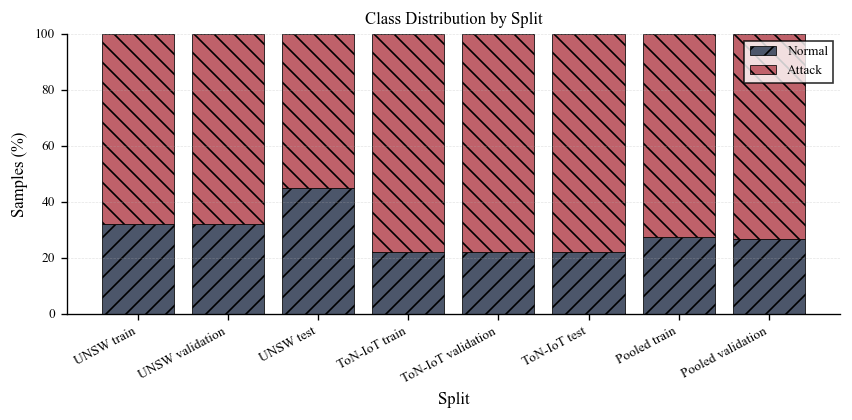

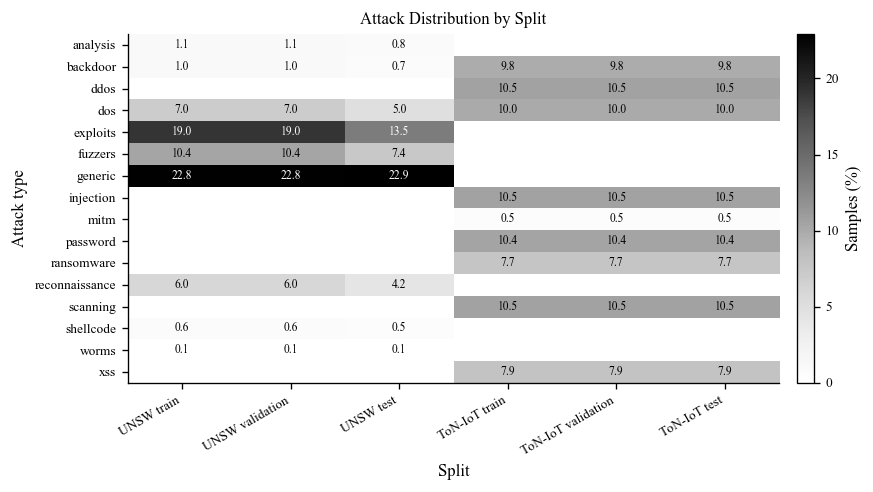

Split summary


,split,rows,normal,attack,attack_percent,attack_types,datasets
0,UNSW train,140272,44800,95472,68.062,10,UNSW-NB15
1,UNSW validation,35069,11200,23869,68.063,10,UNSW-NB15
2,UNSW test,82332,37000,45332,55.060,10,UNSW-NB15
3,ToN-IoT train,114284,25224,89060,77.929,10,ToN-IoT
4,ToN-IoT validation,38095,8408,29687,77.929,10,ToN-IoT
5,ToN-IoT test,38095,8408,29687,77.929,10,ToN-IoT
6,Pooled train,254556,70024,184532,72.492,17,"ToN-IoT, UNSW-NB15"
7,Pooled validation,73164,19608,53556,73.200,17,"ToN-IoT, UNSW-NB15"



Preprocessing summary


,source,train_rows,validation_rows,test_rows,encoded_features,numeric_features,one_hot_features
0,UNSW,140272,35069,82332,170,15,155
1,ToN-IoT,114284,38095,38095,40,15,25
2,Pooled,254556,73164,82332,187,15,172



Attack distribution


,split,attack_type,count,percent
0,UNSW train,normal,44800,31.938
1,UNSW train,generic,32000,22.813
2,UNSW train,exploits,26714,19.044
3,UNSW train,fuzzers,14547,10.371
4,UNSW train,dos,9811,6.994
5,UNSW train,reconnaissance,8393,5.983
6,UNSW train,analysis,1600,1.141
7,UNSW train,backdoor,1397,0.996
8,UNSW train,shellcode,906,0.646
9,UNSW train,worms,104,0.074



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\split_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\attack_distribution_by_split.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\preprocessing_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\protocols.json
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\class_distribution_by_split.pdf
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\attack_distribution_by_split.pdf


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

import matplotlib as mpl
import matplotlib.pyplot as plt


try:
    unsw_train_canon
    unsw_test_canon
    ton_canon
except NameError:
    unsw_train_canon = pd.read_parquet(OUT_DIR / "unsw_train.parquet")
    unsw_test_canon = pd.read_parquet(OUT_DIR / "unsw_test.parquet")
    ton_canon = pd.read_parquet(OUT_DIR / "ton_iot.parquet")

with open(OUT_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

numeric_features = feature_info["numeric_features"]
categorical_features = feature_info["categorical_features"]
model_features = feature_info["model_features"]


unsw_train_split, unsw_val_split = train_test_split(
    unsw_train_canon,
    test_size=0.20,
    random_state=SEED,
    stratify=unsw_train_canon["attack_type"],
)

unsw_train_split = unsw_train_split.reset_index(drop=True)
unsw_val_split = unsw_val_split.reset_index(drop=True)
unsw_test_split = unsw_test_canon.reset_index(drop=True)

unsw_train_split["split"] = "train"
unsw_val_split["split"] = "validation"
unsw_test_split["split"] = "test"


ton_train_val, ton_test_split = train_test_split(
    ton_canon,
    test_size=0.20,
    random_state=SEED,
    stratify=ton_canon["attack_type"],
)

ton_train_split, ton_val_split = train_test_split(
    ton_train_val,
    test_size=0.25,
    random_state=SEED,
    stratify=ton_train_val["attack_type"],
)

ton_train_split = ton_train_split.reset_index(drop=True)
ton_val_split = ton_val_split.reset_index(drop=True)
ton_test_split = ton_test_split.reset_index(drop=True)

ton_train_split["split"] = "train"
ton_val_split["split"] = "validation"
ton_test_split["split"] = "test"


pooled_train_split = pd.concat(
    [unsw_train_split, ton_train_split],
    ignore_index=True,
)

pooled_val_split = pd.concat(
    [unsw_val_split, ton_val_split],
    ignore_index=True,
)


split_data = {
    "unsw_train_split": unsw_train_split,
    "unsw_val_split": unsw_val_split,
    "unsw_test_split": unsw_test_split,
    "ton_train_split": ton_train_split,
    "ton_val_split": ton_val_split,
    "ton_test_split": ton_test_split,
    "pooled_train_split": pooled_train_split,
    "pooled_val_split": pooled_val_split,
}

for name, df in split_data.items():
    df.to_parquet(OUT_DIR / f"{name}.parquet", index=False)


def summarize_split(name, df):
    return {
        "split": name,
        "rows": len(df),
        "normal": int((df["label"] == 0).sum()),
        "attack": int((df["label"] == 1).sum()),
        "attack_percent": round(df["label"].mean() * 100, 3),
        "attack_types": int(df["attack_type"].nunique()),
        "datasets": ", ".join(sorted(df["dataset"].unique())),
    }


split_summary = pd.DataFrame([
    summarize_split("UNSW train", unsw_train_split),
    summarize_split("UNSW validation", unsw_val_split),
    summarize_split("UNSW test", unsw_test_split),
    summarize_split("ToN-IoT train", ton_train_split),
    summarize_split("ToN-IoT validation", ton_val_split),
    summarize_split("ToN-IoT test", ton_test_split),
    summarize_split("Pooled train", pooled_train_split),
    summarize_split("Pooled validation", pooled_val_split),
])

split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)


attack_split_rows = []

for name, df in {
    "UNSW train": unsw_train_split,
    "UNSW validation": unsw_val_split,
    "UNSW test": unsw_test_split,
    "ToN-IoT train": ton_train_split,
    "ToN-IoT validation": ton_val_split,
    "ToN-IoT test": ton_test_split,
}.items():
    counts = df["attack_type"].value_counts().reset_index()
    counts.columns = ["attack_type", "count"]
    counts["split"] = name
    counts["percent"] = (counts["count"] / len(df) * 100).round(3)

    attack_split_rows.append(counts[["split", "attack_type", "count", "percent"]])

attack_split_distribution = pd.concat(attack_split_rows, ignore_index=True)
attack_split_distribution.to_csv(TABLE_DIR / "attack_distribution_by_split.csv", index=False)


def signed_log1p_array(x):
    x = np.asarray(x, dtype=np.float64)
    return np.sign(x) * np.log1p(np.abs(x))


def build_preprocessor():
    numeric_pipe = Pipeline(steps=[
        ("signed_log1p", FunctionTransformer(
            signed_log1p_array,
            feature_names_out="one-to-one",
        )),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def preprocessor_shape(name, train_df, val_df, test_df):
    preprocessor = build_preprocessor()

    x_train = preprocessor.fit_transform(train_df[model_features])
    x_val = preprocessor.transform(val_df[model_features])
    x_test = preprocessor.transform(test_df[model_features])

    return {
        "source": name,
        "train_rows": x_train.shape[0],
        "validation_rows": x_val.shape[0],
        "test_rows": x_test.shape[0],
        "encoded_features": x_train.shape[1],
        "numeric_features": len(numeric_features),
        "one_hot_features": x_train.shape[1] - len(numeric_features),
    }


preprocessing_summary = pd.DataFrame([
    preprocessor_shape("UNSW", unsw_train_split, unsw_val_split, unsw_test_split),
    preprocessor_shape("ToN-IoT", ton_train_split, ton_val_split, ton_test_split),
    preprocessor_shape("Pooled", pooled_train_split, pooled_val_split, unsw_test_split),
])

preprocessing_summary.to_csv(TABLE_DIR / "preprocessing_summary.csv", index=False)


protocols = {
    "E1_UNSW_within": {
        "train": "unsw_train_split",
        "validation": "unsw_val_split",
        "test": "unsw_test_split",
    },
    "E2_ToN_within": {
        "train": "ton_train_split",
        "validation": "ton_val_split",
        "test": "ton_test_split",
    },
    "E3_UNSW_to_ToN": {
        "train": "unsw_train_split",
        "validation": "unsw_val_split",
        "test": "ton_test_split",
    },
    "E4_ToN_to_UNSW": {
        "train": "ton_train_split",
        "validation": "ton_val_split",
        "test": "unsw_test_split",
    },
    "E5_Pooled_to_UNSW": {
        "train": "pooled_train_split",
        "validation": "pooled_val_split",
        "test": "unsw_test_split",
    },
    "E5_Pooled_to_ToN": {
        "train": "pooled_train_split",
        "validation": "pooled_val_split",
        "test": "ton_test_split",
    },
}

with open(OUT_DIR / "protocols.json", "w", encoding="utf-8") as f:
    json.dump(protocols, f, indent=4)


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})

normal_color = "#4C566A"
attack_color = "#BF616A"

plot_df = split_summary.copy()
plot_df["normal_percent"] = 100 - plot_df["attack_percent"]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
x = np.arange(len(plot_df))

ax.bar(
    x,
    plot_df["normal_percent"],
    label="Normal",
    color=normal_color,
    edgecolor="black",
    linewidth=0.45,
    hatch="//",
)

ax.bar(
    x,
    plot_df["attack_percent"],
    bottom=plot_df["normal_percent"],
    label="Attack",
    color=attack_color,
    edgecolor="black",
    linewidth=0.45,
    hatch="\\\\",
)

ax.set_ylabel("Samples (%)")
ax.set_xlabel("Split")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["split"], rotation=28, ha="right")
ax.set_title("Class Distribution by Split")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, edgecolor="black", fancybox=False, loc="upper right")

plt.tight_layout()

class_plot_pdf = FIG_DIR / "class_distribution_by_split.pdf"
class_plot_png = FIG_DIR / "class_distribution_by_split.png"

plt.savefig(class_plot_pdf, bbox_inches="tight")
plt.savefig(class_plot_png, bbox_inches="tight")
plt.show()


family_plot = attack_split_distribution[
    attack_split_distribution["attack_type"] != "normal"
].copy()

family_pivot = family_plot.pivot_table(
    index="attack_type",
    columns="split",
    values="percent",
    fill_value=0,
)

ordered_columns = [
    "UNSW train",
    "UNSW validation",
    "UNSW test",
    "ToN-IoT train",
    "ToN-IoT validation",
    "ToN-IoT test",
]

family_pivot = family_pivot[
    [col for col in ordered_columns if col in family_pivot.columns]
]

fig, ax = plt.subplots(figsize=(7.4, 4.2))

im = ax.imshow(
    family_pivot.values,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
)

ax.set_xticks(np.arange(family_pivot.shape[1]))
ax.set_xticklabels(family_pivot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(family_pivot.shape[0]))
ax.set_yticklabels(family_pivot.index)

ax.set_xlabel("Split")
ax.set_ylabel("Attack type")
ax.set_title("Attack Distribution by Split")

for i in range(family_pivot.shape[0]):
    for j in range(family_pivot.shape[1]):
        value = family_pivot.iloc[i, j]

        if value > 0:
            text_color = "white" if value > family_pivot.values.max() * 0.55 else "black"
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color=text_color,
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("Samples (%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

family_plot_pdf = FIG_DIR / "attack_distribution_by_split.pdf"
family_plot_png = FIG_DIR / "attack_distribution_by_split.png"

plt.savefig(family_plot_pdf, bbox_inches="tight")
plt.savefig(family_plot_png, bbox_inches="tight")
plt.show()


print("Split summary")
display(split_summary)

print("\nPreprocessing summary")
display(preprocessing_summary)

print("\nAttack distribution")
display(attack_split_distribution)

print("\nSaved files")
print(f"- {TABLE_DIR / 'split_summary.csv'}")
print(f"- {TABLE_DIR / 'attack_distribution_by_split.csv'}")
print(f"- {TABLE_DIR / 'preprocessing_summary.csv'}")
print(f"- {OUT_DIR / 'protocols.json'}")
print(f"- {class_plot_pdf}")
print(f"- {family_plot_pdf}")

## 5. Baseline models

Train classical baseline models under within-dataset, cross-dataset, and pooled-training protocols.


E1_UNSW_within
Logistic Regression  val_f1=0.9026 test_f1=0.8108 test_auc=0.9083 time=14.0s
Random Forest        val_f1=0.9595 test_f1=0.9061 test_auc=0.9788 time=5.6s
XGBoost              val_f1=0.9504 test_f1=0.9245 test_auc=0.9801 time=1.8s
LightGBM             val_f1=0.9552 test_f1=0.9217 test_auc=0.9812 time=1.6s

E2_ToN_within
Logistic Regression  val_f1=0.9813 test_f1=0.9821 test_auc=0.9903 time=5.7s
Random Forest        val_f1=0.9978 test_f1=0.9974 test_auc=0.9998 time=3.0s
XGBoost              val_f1=0.9970 test_f1=0.9968 test_auc=0.9997 time=0.8s
LightGBM             val_f1=0.9977 test_f1=0.9975 test_auc=0.9997 time=1.4s

E3_UNSW_to_ToN
Logistic Regression  val_f1=0.9026 test_f1=0.3818 test_auc=0.2899 time=13.6s
Random Forest        val_f1=0.9595 test_f1=0.4425 test_auc=0.2037 time=5.5s
XGBoost              val_f1=0.9504 test_f1=0.5610 test_auc=0.1338 time=2.2s
LightGBM             val_f1=0.9552 test_f1=0.4967 test_auc=0.1186 time=1.8s

E4_ToN_to_UNSW
Logistic Regression  va

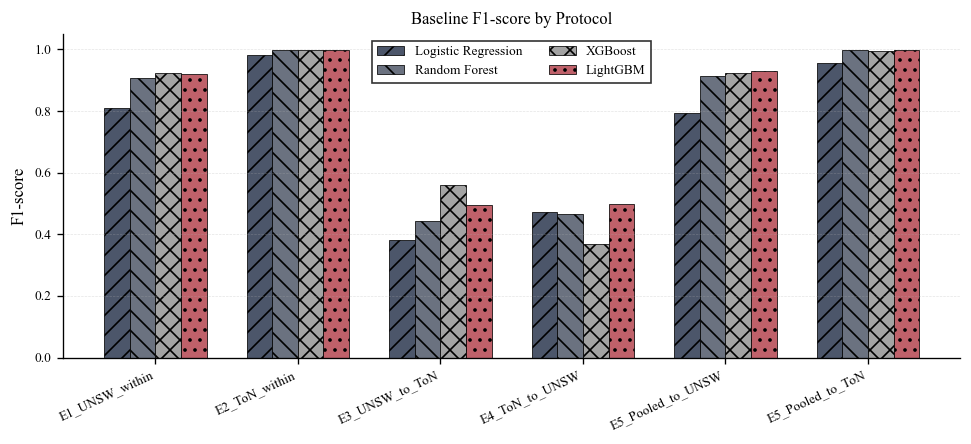

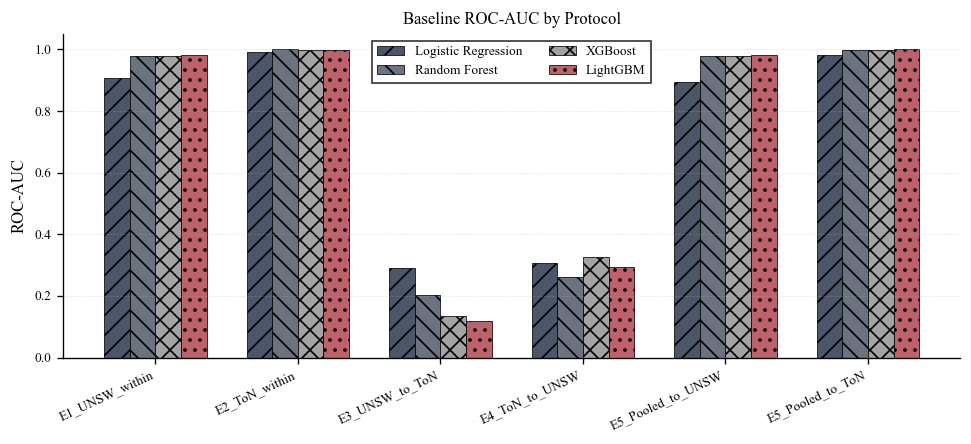


Baseline test results


,protocol,model,test_name,eval_rows,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,fpr,fnr
5,E1_UNSW_within,XGBoost,UNSW test,82332,0.916132,0.914307,0.916752,0.932344,0.924482,0.980106,0.985590,0.830353,0.103730,0.067656
7,E1_UNSW_within,LightGBM,UNSW test,82332,0.912148,0.909102,0.904852,0.939204,0.921708,0.981196,0.986367,0.822457,0.121000,0.060796
3,E1_UNSW_within,Random Forest,UNSW test,82332,0.890857,0.883426,0.860532,0.956852,0.906140,0.978779,0.984599,0.782891,0.190000,0.043148
1,E1_UNSW_within,Logistic Regression,UNSW test,82332,0.778094,0.768483,0.764164,0.863452,0.810779,0.908334,0.934660,0.550898,0.326486,0.136548
15,E2_ToN_within,LightGBM,ToN-IoT test,38095,0.996167,0.996092,0.998852,0.996227,0.997538,0.999710,0.999895,0.988913,0.004044,0.003773
11,E2_ToN_within,Random Forest,ToN-IoT test,38095,0.995931,0.995258,0.998313,0.996463,0.997387,0.999753,0.999915,0.988208,0.005947,0.003537
13,E2_ToN_within,XGBoost,ToN-IoT test,38095,0.994960,0.995019,0.998614,0.994914,0.996760,0.999702,0.999892,0.985451,0.004876,0.005086
9,E2_ToN_within,Logistic Regression,ToN-IoT test,38095,0.972385,0.972308,0.991960,0.972446,0.982106,0.990301,0.996686,0.922545,0.027831,0.027554
21,E3_UNSW_to_ToN,XGBoost,ToN-IoT test,38095,0.399580,0.282376,0.652030,0.492202,0.560954,0.133771,0.617952,-0.366778,0.927450,0.507798
23,E3_UNSW_to_ToN,LightGBM,ToN-IoT test,38095,0.338076,0.235455,0.609492,0.419173,0.496727,0.118590,0.618618,-0.439994,0.948264,0.580827



Best baseline per protocol


,protocol,model,test_name,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,fpr,fnr
0,E1_UNSW_within,XGBoost,UNSW test,0.916132,0.914307,0.916752,0.932344,0.924482,0.980106,0.985590,0.830353,0.103730,0.067656
1,E2_ToN_within,LightGBM,ToN-IoT test,0.996167,0.996092,0.998852,0.996227,0.997538,0.999710,0.999895,0.988913,0.004044,0.003773
2,E3_UNSW_to_ToN,XGBoost,ToN-IoT test,0.399580,0.282376,0.652030,0.492202,0.560954,0.133771,0.617952,-0.366778,0.927450,0.507798
3,E4_ToN_to_UNSW,LightGBM,UNSW test,0.373743,0.352056,0.445907,0.566355,0.498965,0.293473,0.438323,-0.320978,0.862243,0.433645
4,E5_Pooled_to_ToN,Random Forest,ToN-IoT test,0.995747,0.994799,0.998043,0.996497,0.997269,0.999711,0.999902,0.987668,0.006898,0.003503
5,E5_Pooled_to_UNSW,LightGBM,UNSW test,0.922995,0.922859,0.935179,0.924204,0.929659,0.980942,0.986233,0.844673,0.078486,0.075796



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\baseline_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\baseline_test_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\best_baselines.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\baseline_confusions.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\baselines\baseline_f1.pdf
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\baselines\baseline_roc_auc.pdf
- models saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\baselines


In [5]:
import time
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False


BASELINE_MODEL_DIR = MODEL_DIR / "baselines"
BASELINE_FIG_DIR = FIG_DIR / "baselines"

BASELINE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_FIG_DIR.mkdir(parents=True, exist_ok=True)


try:
    unsw_train_split
    unsw_val_split
    unsw_test_split
    ton_train_split
    ton_val_split
    ton_test_split
    pooled_train_split
    pooled_val_split
except NameError:
    unsw_train_split = pd.read_parquet(OUT_DIR / "unsw_train_split.parquet")
    unsw_val_split = pd.read_parquet(OUT_DIR / "unsw_val_split.parquet")
    unsw_test_split = pd.read_parquet(OUT_DIR / "unsw_test_split.parquet")

    ton_train_split = pd.read_parquet(OUT_DIR / "ton_train_split.parquet")
    ton_val_split = pd.read_parquet(OUT_DIR / "ton_val_split.parquet")
    ton_test_split = pd.read_parquet(OUT_DIR / "ton_test_split.parquet")

    pooled_train_split = pd.read_parquet(OUT_DIR / "pooled_train_split.parquet")
    pooled_val_split = pd.read_parquet(OUT_DIR / "pooled_val_split.parquet")


with open(OUT_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

numeric_features = feature_info["numeric_features"]
categorical_features = feature_info["categorical_features"]
model_features = feature_info["model_features"]


if "build_preprocessor" not in globals():

    def signed_log1p_array(x):
        x = np.asarray(x, dtype=np.float64)
        return np.sign(x) * np.log1p(np.abs(x))


    def build_preprocessor():
        numeric_pipe = Pipeline(steps=[
            ("signed_log1p", FunctionTransformer(
                signed_log1p_array,
                feature_names_out="one-to-one",
            )),
            ("scaler", StandardScaler()),
        ])

        categorical_pipe = Pipeline(steps=[
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )),
        ])

        return ColumnTransformer(
            transformers=[
                ("num", numeric_pipe, numeric_features),
                ("cat", categorical_pipe, categorical_features),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )


def get_xy(df):
    return df[model_features].copy(), df["label"].astype(int).values


def positive_weight(y):
    n_pos = np.sum(y == 1)
    n_neg = np.sum(y == 0)

    if n_pos == 0:
        return 1.0

    return float(n_neg / n_pos)


def predict_score(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]

    if hasattr(model, "decision_function"):
        raw_score = model.decision_function(x)
        return 1.0 / (1.0 + np.exp(-raw_score))

    return model.predict(x).astype(float)


def evaluate_binary(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except Exception:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_score)
    except Exception:
        pr_auc = np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "fpr": fp / (fp + tn + 1e-9),
        "fnr": fn / (fn + tp + 1e-9),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def make_baseline_models(y_train):
    scale_pos_weight = positive_weight(y_train)

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            n_jobs=-1,
            random_state=SEED,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=160,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.90,
            colsample_bytree=0.90,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=SEED,
        )

    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.90,
            colsample_bytree=0.90,
            class_weight="balanced",
            objective="binary",
            random_state=SEED,
            n_jobs=-1,
            verbose=-1,
        )

    return models


def clean_name(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def plot_confusion_matrix(cm, title, save_name):
    cm = np.asarray(cm)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(3.3, 2.8))

    im = ax.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Attack"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Normal", "Attack"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            text_color = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n{cm_norm[i, j] * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    cbar.set_label("Row-normalized rate")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    pdf_path = BASELINE_FIG_DIR / f"{save_name}.pdf"
    png_path = BASELINE_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return pdf_path, png_path


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})


baseline_protocols = {
    "E1_UNSW_within": {
        "train": unsw_train_split,
        "validation": unsw_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E2_ToN_within": {
        "train": ton_train_split,
        "validation": ton_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
    "E3_UNSW_to_ToN": {
        "train": unsw_train_split,
        "validation": unsw_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
    "E4_ToN_to_UNSW": {
        "train": ton_train_split,
        "validation": ton_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E5_Pooled_to_UNSW": {
        "train": pooled_train_split,
        "validation": pooled_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E5_Pooled_to_ToN": {
        "train": pooled_train_split,
        "validation": pooled_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
}


baseline_rows = []
confusion_rows = []

for protocol_name, data in baseline_protocols.items():
    print(f"\n{protocol_name}")

    x_train, y_train = get_xy(data["train"])
    x_val, y_val = get_xy(data["validation"])
    x_test, y_test = get_xy(data["test"])

    for model_name, classifier in make_baseline_models(y_train).items():
        start_time = time.time()

        pipeline = Pipeline(steps=[
            ("preprocess", build_preprocessor()),
            ("model", classifier),
        ])

        pipeline.fit(x_train, y_train)

        train_time = time.time() - start_time

        val_score = predict_score(pipeline, x_val)
        test_score = predict_score(pipeline, x_test)

        val_metrics = evaluate_binary(y_val, val_score)
        test_metrics = evaluate_binary(y_test, test_score)

        model_id = f"{clean_name(protocol_name)}__{clean_name(model_name)}"
        model_path = BASELINE_MODEL_DIR / f"{model_id}.joblib"
        joblib.dump(pipeline, model_path)

        for split_name, eval_df, eval_y, metrics, test_name in [
            ("validation", data["validation"], y_val, val_metrics, "validation"),
            ("test", data["test"], y_test, test_metrics, data["test_name"]),
        ]:
            row = {
                "protocol": protocol_name,
                "model": model_name,
                "split": split_name,
                "test_name": test_name,
                "train_rows": len(data["train"]),
                "eval_rows": len(eval_df),
                "train_attack_percent": round(np.mean(y_train) * 100, 3),
                "eval_attack_percent": round(np.mean(eval_y) * 100, 3),
                "train_time_sec": round(train_time, 3),
                "model_path": str(model_path),
            }

            row.update({
                key: round(value, 6) if isinstance(value, float) else value
                for key, value in metrics.items()
            })

            baseline_rows.append(row)

        cm = np.array([
            [test_metrics["tn"], test_metrics["fp"]],
            [test_metrics["fn"], test_metrics["tp"]],
        ])

        cm_pdf, cm_png = plot_confusion_matrix(
            cm,
            title=f"{model_name}\n{protocol_name}",
            save_name=f"cm_{model_id}",
        )

        confusion_rows.append({
            "protocol": protocol_name,
            "model": model_name,
            "tn": test_metrics["tn"],
            "fp": test_metrics["fp"],
            "fn": test_metrics["fn"],
            "tp": test_metrics["tp"],
            "figure_pdf": str(cm_pdf),
            "figure_png": str(cm_png),
        })

        print(
            f"{model_name:20s} "
            f"val_f1={val_metrics['f1']:.4f} "
            f"test_f1={test_metrics['f1']:.4f} "
            f"test_auc={test_metrics['roc_auc']:.4f} "
            f"time={train_time:.1f}s"
        )


baseline_results = pd.DataFrame(baseline_rows)
baseline_confusions = pd.DataFrame(confusion_rows)

baseline_results.to_csv(TABLE_DIR / "baseline_results.csv", index=False)
baseline_confusions.to_csv(TABLE_DIR / "baseline_confusions.csv", index=False)

baseline_test_results = baseline_results[
    baseline_results["split"] == "test"
].copy()

baseline_test_results = baseline_test_results.sort_values(
    ["protocol", "f1", "roc_auc"],
    ascending=[True, False, False],
)

baseline_test_results.to_csv(TABLE_DIR / "baseline_test_results.csv", index=False)

best_baselines = (
    baseline_test_results
    .sort_values(["protocol", "f1", "roc_auc", "mcc"], ascending=[True, False, False, False])
    .groupby("protocol", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_baselines.to_csv(TABLE_DIR / "best_baselines.csv", index=False)


plot_df = baseline_test_results.copy()
model_order = [
    model for model in [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
    ]
    if model in plot_df["model"].unique()
]

protocol_order = list(baseline_protocols.keys())

hatches = ["//", "\\\\", "xx", ".."]
colors = ["#4C566A", "#6B7280", "#A3A3A3", "#BF616A"]


def grouped_metric_plot(metric, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(8.2, 3.8))

    x = np.arange(len(protocol_order))
    width = 0.18

    for idx, model_name in enumerate(model_order):
        values = []

        for protocol_name in protocol_order:
            subset = plot_df[
                (plot_df["protocol"] == protocol_name)
                & (plot_df["model"] == model_name)
            ]

            values.append(subset[metric].iloc[0] if len(subset) else np.nan)

        ax.bar(
            x + (idx - (len(model_order) - 1) / 2) * width,
            values,
            width,
            label=model_name,
            color=colors[idx % len(colors)],
            edgecolor="black",
            linewidth=0.45,
            hatch=hatches[idx % len(hatches)],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(protocol_order, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, edgecolor="black", fancybox=False, ncol=2)

    plt.tight_layout()

    pdf_path = BASELINE_FIG_DIR / f"{save_name}.pdf"
    png_path = BASELINE_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.show()

    return pdf_path, png_path


f1_pdf, f1_png = grouped_metric_plot(
    metric="f1",
    ylabel="F1-score",
    title="Baseline F1-score by Protocol",
    save_name="baseline_f1",
)

auc_pdf, auc_png = grouped_metric_plot(
    metric="roc_auc",
    ylabel="ROC-AUC",
    title="Baseline ROC-AUC by Protocol",
    save_name="baseline_roc_auc",
)


print("\nBaseline test results")
display(baseline_test_results[
    [
        "protocol",
        "model",
        "test_name",
        "eval_rows",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "mcc",
        "fpr",
        "fnr",
    ]
])

print("\nBest baseline per protocol")
display(best_baselines[
    [
        "protocol",
        "model",
        "test_name",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "mcc",
        "fpr",
        "fnr",
    ]
])

print("\nSaved files")
print(f"- {TABLE_DIR / 'baseline_results.csv'}")
print(f"- {TABLE_DIR / 'baseline_test_results.csv'}")
print(f"- {TABLE_DIR / 'best_baselines.csv'}")
print(f"- {TABLE_DIR / 'baseline_confusions.csv'}")
print(f"- {f1_pdf}")
print(f"- {auc_pdf}")
print(f"- models saved in {BASELINE_MODEL_DIR}")

## 6. Residual MLP

Train a residual multilayer perceptron using the same evaluation protocols as the baseline models.

Device: cuda

E1_UNSW_within
E1_UNSW_within     epoch=01 loss=0.1580 val_f1=0.9508 val_auc=0.9799 threshold=0.31
E1_UNSW_within     epoch=02 loss=0.1088 val_f1=0.9534 val_auc=0.9829 threshold=0.19
E1_UNSW_within     epoch=03 loss=0.1029 val_f1=0.9542 val_auc=0.9833 threshold=0.29
E1_UNSW_within     epoch=04 loss=0.1005 val_f1=0.9550 val_auc=0.9844 threshold=0.30
E1_UNSW_within     epoch=05 loss=0.0981 val_f1=0.9548 val_auc=0.9843 threshold=0.28
E1_UNSW_within     epoch=06 loss=0.0977 val_f1=0.9550 val_auc=0.9855 threshold=0.25
E1_UNSW_within     epoch=07 loss=0.0965 val_f1=0.9551 val_auc=0.9855 threshold=0.28
E1_UNSW_within     epoch=08 loss=0.0957 val_f1=0.9551 val_auc=0.9856 threshold=0.28
E1_UNSW_within     epoch=09 loss=0.0946 val_f1=0.9549 val_auc=0.9858 threshold=0.22
E1_UNSW_within     epoch=10 loss=0.0938 val_f1=0.9560 val_auc=0.9860 threshold=0.30
E1_UNSW_within     epoch=11 loss=0.0937 val_f1=0.9564 val_auc=0.9864 threshold=0.28
E1_UNSW_within     epoch=12 loss=0.0931 val_f1=

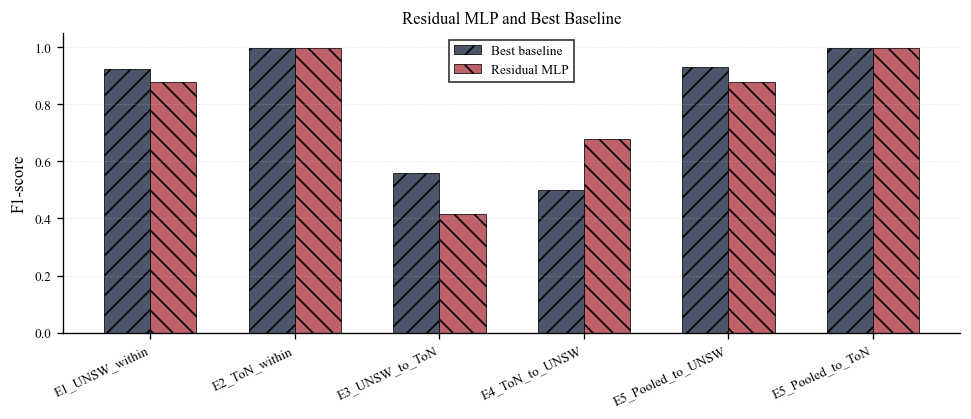


Residual MLP test results


,protocol,model,test_name,eval_rows,input_dim,threshold,best_epoch,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,fpr,fnr
1,E1_UNSW_within,Residual MLP,UNSW test,82332,170,0.325,31,0.853119,0.839646,0.802409,0.972779,0.879418,0.974105,0.981101,0.717251,0.293486,0.027221
3,E2_ToN_within,Residual MLP,ToN-IoT test,38095,40,0.180,44,0.995222,0.993226,0.997069,0.996800,0.996934,0.999412,0.999745,0.986117,0.010347,0.003200
5,E3_UNSW_to_ToN,Residual MLP,ToN-IoT test,38095,170,0.315,31,0.346843,0.407914,0.685909,0.298582,0.416053,0.211682,0.658931,-0.161330,0.482755,0.701418
7,E4_ToN_to_UNSW,Residual MLP,UNSW test,82332,40,0.130,21,0.533717,0.493409,0.546966,0.891710,0.678033,0.518654,0.558421,-0.021631,0.904892,0.108290
9,E5_Pooled_to_UNSW,Residual MLP,UNSW test,82332,187,0.275,42,0.850119,0.835769,0.796488,0.977566,0.877785,0.973193,0.980048,0.713644,0.306027,0.022434
11,E5_Pooled_to_ToN,Residual MLP,ToN-IoT test,38095,187,0.255,24,0.994802,0.992829,0.996967,0.996362,0.996664,0.999251,0.999703,0.984903,0.010704,0.003638



Residual MLP vs baseline


,protocol,test_name,best_baseline,baseline_f1,residual_mlp_f1,delta_f1,baseline_roc_auc,residual_mlp_roc_auc,delta_roc_auc,baseline_mcc,residual_mlp_mcc,delta_mcc
0,E1_UNSW_within,UNSW test,XGBoost,0.924482,0.879418,-0.045064,0.980106,0.974105,-0.006001,0.830353,0.717251,-0.113102
1,E2_ToN_within,ToN-IoT test,LightGBM,0.997538,0.996934,-0.000604,0.999710,0.999412,-0.000298,0.988913,0.986117,-0.002796
2,E3_UNSW_to_ToN,ToN-IoT test,XGBoost,0.560954,0.416053,-0.144901,0.133771,0.211682,0.077911,-0.366778,-0.161330,0.205448
3,E4_ToN_to_UNSW,UNSW test,LightGBM,0.498965,0.678033,0.179068,0.293473,0.518654,0.225181,-0.320978,-0.021631,0.299347
4,E5_Pooled_to_UNSW,UNSW test,LightGBM,0.929659,0.877785,-0.051874,0.980942,0.973193,-0.007749,0.844673,0.713644,-0.131029
5,E5_Pooled_to_ToN,ToN-IoT test,Random Forest,0.997269,0.996664,-0.000605,0.999711,0.999251,-0.000460,0.987668,0.984903,-0.002765



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_test_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_history.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_confusions.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_vs_baseline.csv
- models saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\residual_mlp
- figures saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\residual_mlp


In [6]:
import copy
import time
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


MLP_MODEL_DIR = MODEL_DIR / "residual_mlp"
MLP_FIG_DIR = FIG_DIR / "residual_mlp"

MLP_MODEL_DIR.mkdir(parents=True, exist_ok=True)
MLP_FIG_DIR.mkdir(parents=True, exist_ok=True)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

print(f"Device: {DEVICE}")


try:
    unsw_train_split
    unsw_val_split
    unsw_test_split
    ton_train_split
    ton_val_split
    ton_test_split
    pooled_train_split
    pooled_val_split
except NameError:
    unsw_train_split = pd.read_parquet(OUT_DIR / "unsw_train_split.parquet")
    unsw_val_split = pd.read_parquet(OUT_DIR / "unsw_val_split.parquet")
    unsw_test_split = pd.read_parquet(OUT_DIR / "unsw_test_split.parquet")

    ton_train_split = pd.read_parquet(OUT_DIR / "ton_train_split.parquet")
    ton_val_split = pd.read_parquet(OUT_DIR / "ton_val_split.parquet")
    ton_test_split = pd.read_parquet(OUT_DIR / "ton_test_split.parquet")

    pooled_train_split = pd.read_parquet(OUT_DIR / "pooled_train_split.parquet")
    pooled_val_split = pd.read_parquet(OUT_DIR / "pooled_val_split.parquet")


with open(OUT_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

numeric_features = feature_info["numeric_features"]
categorical_features = feature_info["categorical_features"]
model_features = feature_info["model_features"]


if "build_preprocessor" not in globals():

    def signed_log1p_array(x):
        x = np.asarray(x, dtype=np.float64)
        return np.sign(x) * np.log1p(np.abs(x))


    def build_preprocessor():
        numeric_pipe = Pipeline(steps=[
            ("signed_log1p", FunctionTransformer(
                signed_log1p_array,
                feature_names_out="one-to-one",
            )),
            ("scaler", StandardScaler()),
        ])

        categorical_pipe = Pipeline(steps=[
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )),
        ])

        return ColumnTransformer(
            transformers=[
                ("num", numeric_pipe, numeric_features),
                ("cat", categorical_pipe, categorical_features),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )


if "evaluate_binary" not in globals():

    def evaluate_binary(y_true, y_score, threshold=0.5):
        y_pred = (y_score >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        try:
            roc_auc = roc_auc_score(y_true, y_score)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, y_score)
        except Exception:
            pr_auc = np.nan

        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "mcc": matthews_corrcoef(y_true, y_pred),
            "fpr": fp / (fp + tn + 1e-9),
            "fnr": fn / (fn + tp + 1e-9),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }


if "clean_name" not in globals():

    def clean_name(text):
        return (
            str(text)
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
            .replace("/", "_")
        )


def get_xy(df):
    return df[model_features].copy(), df["label"].astype(int).values


def best_threshold(y_true, y_score):
    thresholds = np.linspace(0.05, 0.95, 181)

    scores = [
        f1_score(y_true, (y_score >= threshold).astype(int), zero_division=0)
        for threshold in thresholds
    ]

    best_idx = int(np.argmax(scores))

    return float(thresholds[best_idx]), float(scores[best_idx])


def make_loader(x, y, batch_size=2048, shuffle=False):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    dataset = TensorDataset(x_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.20):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
        )

        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.layers(x))


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, n_blocks=3, dropout=0.20):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.blocks = nn.Sequential(*[
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.output_layer(x)


def predict_mlp(model, loader):
    model.eval()

    scores = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            scores.append(torch.sigmoid(logits).cpu().numpy().ravel())

    return np.concatenate(scores)


def train_mlp(
    x_train,
    y_train,
    x_val,
    y_val,
    input_dim,
    protocol_name,
    max_epochs=45,
    batch_size=2048,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=8,
):
    model = ResidualMLP(
        input_dim=input_dim,
        hidden_dim=128,
        n_blocks=3,
        dropout=0.20,
    ).to(DEVICE)

    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    pos_weight = float(n_neg / max(n_pos, 1))

    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    train_loader = make_loader(x_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(x_val, y_val, batch_size=batch_size, shuffle=False)

    history = []
    best_state = None
    best_val_f1 = -1.0
    patience_count = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = loss_fn(logits, yb)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            losses.append(loss.item())

        val_score = predict_mlp(model, val_loader)
        threshold, val_f1 = best_threshold(y_val, val_score)
        val_metrics = evaluate_binary(y_val, val_score, threshold=threshold)

        scheduler.step(val_f1)

        history.append({
            "protocol": protocol_name,
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "threshold": threshold,
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_count = 0

            best_state = {
                "model_state": copy.deepcopy(model.state_dict()),
                "threshold": threshold,
                "epoch": epoch,
                "val_f1": val_f1,
            }
        else:
            patience_count += 1

        print(
            f"{protocol_name:18s} "
            f"epoch={epoch:02d} "
            f"loss={np.mean(losses):.4f} "
            f"val_f1={val_metrics['f1']:.4f} "
            f"val_auc={val_metrics['roc_auc']:.4f} "
            f"threshold={threshold:.2f}"
        )

        if patience_count >= patience:
            break

    model.load_state_dict(best_state["model_state"])

    return model, pd.DataFrame(history), best_state


def plot_training_curve(history, protocol_name):
    fig, ax = plt.subplots(figsize=(5.8, 3.2))

    ax.plot(
        history["epoch"],
        history["val_f1"],
        marker="o",
        markersize=3,
        label="Validation F1",
        color="#4C566A",
    )

    ax.plot(
        history["epoch"],
        history["val_roc_auc"],
        marker="s",
        markersize=3,
        label="Validation ROC-AUC",
        color="#BF616A",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Training Curve: {protocol_name}")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, edgecolor="black", fancybox=False)

    plt.tight_layout()

    save_name = f"training_curve_{clean_name(protocol_name)}"
    pdf_path = MLP_FIG_DIR / f"{save_name}.pdf"
    png_path = MLP_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return pdf_path, png_path


def plot_confusion_matrix(cm, title, save_name, save_dir):
    cm = np.asarray(cm)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(3.3, 2.8))

    im = ax.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Attack"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Normal", "Attack"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            text_color = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n{cm_norm[i, j] * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    cbar.set_label("Row-normalized rate")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    pdf_path = save_dir / f"{save_name}.pdf"
    png_path = save_dir / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return pdf_path, png_path


mlp_protocols = {
    "E1_UNSW_within": {
        "train": unsw_train_split,
        "validation": unsw_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E2_ToN_within": {
        "train": ton_train_split,
        "validation": ton_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
    "E3_UNSW_to_ToN": {
        "train": unsw_train_split,
        "validation": unsw_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
    "E4_ToN_to_UNSW": {
        "train": ton_train_split,
        "validation": ton_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E5_Pooled_to_UNSW": {
        "train": pooled_train_split,
        "validation": pooled_val_split,
        "test": unsw_test_split,
        "test_name": "UNSW test",
    },
    "E5_Pooled_to_ToN": {
        "train": pooled_train_split,
        "validation": pooled_val_split,
        "test": ton_test_split,
        "test_name": "ToN-IoT test",
    },
}


mlp_rows = []
mlp_confusion_rows = []
history_tables = []

for protocol_name, data in mlp_protocols.items():
    print(f"\n{protocol_name}")

    train_df = data["train"]
    val_df = data["validation"]
    test_df = data["test"]

    x_train_raw, y_train = get_xy(train_df)
    x_val_raw, y_val = get_xy(val_df)
    x_test_raw, y_test = get_xy(test_df)

    preprocessor = build_preprocessor()

    x_train = preprocessor.fit_transform(x_train_raw).astype(np.float32)
    x_val = preprocessor.transform(x_val_raw).astype(np.float32)
    x_test = preprocessor.transform(x_test_raw).astype(np.float32)

    input_dim = x_train.shape[1]

    start_time = time.time()

    model, history, best_state = train_mlp(
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        input_dim=input_dim,
        protocol_name=protocol_name,
        max_epochs=45,
        batch_size=2048,
        learning_rate=1e-3,
        weight_decay=1e-4,
        patience=8,
    )

    train_time = time.time() - start_time

    history_tables.append(history)

    curve_pdf, curve_png = plot_training_curve(history, protocol_name)

    threshold = float(best_state["threshold"])

    val_loader = make_loader(x_val, y_val, batch_size=4096, shuffle=False)
    test_loader = make_loader(x_test, y_test, batch_size=4096, shuffle=False)

    val_score = predict_mlp(model, val_loader)
    test_score = predict_mlp(model, test_loader)

    val_metrics = evaluate_binary(y_val, val_score, threshold=threshold)
    test_metrics = evaluate_binary(y_test, test_score, threshold=threshold)

    model_id = clean_name(protocol_name)
    model_path = MLP_MODEL_DIR / f"{model_id}.pt"
    preprocessor_path = MLP_MODEL_DIR / f"{model_id}_preprocessor.joblib"
    score_path = MLP_MODEL_DIR / f"{model_id}_test_scores.csv"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "input_dim": input_dim,
            "threshold": threshold,
            "feature_info": feature_info,
            "best_epoch": int(best_state["epoch"]),
            "best_val_f1": float(best_state["val_f1"]),
        },
        model_path,
    )

    joblib.dump(preprocessor, preprocessor_path)

    score_df = test_df[["dataset", "split", "attack_type", "label"]].copy()
    score_df["score"] = test_score
    score_df["prediction"] = (test_score >= threshold).astype(int)
    score_df["correct"] = score_df["prediction"] == score_df["label"]
    score_df.to_csv(score_path, index=False)

    cm = np.array([
        [test_metrics["tn"], test_metrics["fp"]],
        [test_metrics["fn"], test_metrics["tp"]],
    ])

    cm_pdf, cm_png = plot_confusion_matrix(
        cm,
        title=f"Residual MLP\n{protocol_name}",
        save_name=f"cm_{model_id}",
        save_dir=MLP_FIG_DIR,
    )

    for split_name, eval_df, eval_y, metrics, test_name in [
        ("validation", val_df, y_val, val_metrics, "validation"),
        ("test", test_df, y_test, test_metrics, data["test_name"]),
    ]:
        row = {
            "protocol": protocol_name,
            "model": "Residual MLP",
            "split": split_name,
            "test_name": test_name,
            "train_rows": len(train_df),
            "eval_rows": len(eval_df),
            "input_dim": input_dim,
            "train_attack_percent": round(np.mean(y_train) * 100, 3),
            "eval_attack_percent": round(np.mean(eval_y) * 100, 3),
            "threshold": threshold,
            "best_epoch": int(best_state["epoch"]),
            "train_time_sec": round(train_time, 3),
            "model_path": str(model_path),
            "preprocessor_path": str(preprocessor_path),
            "score_path": str(score_path),
        }

        row.update({
            key: round(value, 6) if isinstance(value, float) else value
            for key, value in metrics.items()
        })

        mlp_rows.append(row)

    mlp_confusion_rows.append({
        "protocol": protocol_name,
        "model": "Residual MLP",
        "threshold": threshold,
        "tn": test_metrics["tn"],
        "fp": test_metrics["fp"],
        "fn": test_metrics["fn"],
        "tp": test_metrics["tp"],
        "figure_pdf": str(cm_pdf),
        "figure_png": str(cm_png),
    })

    print(
        f"best_epoch={best_state['epoch']} "
        f"threshold={threshold:.2f} "
        f"test_f1={test_metrics['f1']:.4f} "
        f"test_auc={test_metrics['roc_auc']:.4f} "
        f"time={train_time:.1f}s"
    )


mlp_results = pd.DataFrame(mlp_rows)
mlp_confusions = pd.DataFrame(mlp_confusion_rows)
mlp_history = pd.concat(history_tables, ignore_index=True)

mlp_results.to_csv(TABLE_DIR / "residual_mlp_results.csv", index=False)
mlp_confusions.to_csv(TABLE_DIR / "residual_mlp_confusions.csv", index=False)
mlp_history.to_csv(TABLE_DIR / "residual_mlp_history.csv", index=False)

mlp_test_results = mlp_results[mlp_results["split"] == "test"].copy()
mlp_test_results.to_csv(TABLE_DIR / "residual_mlp_test_results.csv", index=False)


try:
    best_baselines
except NameError:
    best_baselines = pd.read_csv(TABLE_DIR / "best_baselines.csv")

comparison_rows = []

for _, mlp_row in mlp_test_results.iterrows():
    protocol_name = mlp_row["protocol"]

    baseline_match = best_baselines[
        best_baselines["protocol"] == protocol_name
    ]

    if len(baseline_match) == 0:
        continue

    baseline_row = baseline_match.iloc[0]

    comparison_rows.append({
        "protocol": protocol_name,
        "test_name": mlp_row["test_name"],
        "best_baseline": baseline_row["model"],
        "baseline_f1": baseline_row["f1"],
        "residual_mlp_f1": mlp_row["f1"],
        "delta_f1": mlp_row["f1"] - baseline_row["f1"],
        "baseline_roc_auc": baseline_row["roc_auc"],
        "residual_mlp_roc_auc": mlp_row["roc_auc"],
        "delta_roc_auc": mlp_row["roc_auc"] - baseline_row["roc_auc"],
        "baseline_mcc": baseline_row["mcc"],
        "residual_mlp_mcc": mlp_row["mcc"],
        "delta_mcc": mlp_row["mcc"] - baseline_row["mcc"],
    })

mlp_comparison = pd.DataFrame(comparison_rows)
mlp_comparison.to_csv(TABLE_DIR / "residual_mlp_vs_baseline.csv", index=False)


if len(mlp_comparison) > 0:
    plot_df = mlp_comparison.set_index("protocol").loc[list(mlp_protocols.keys())].reset_index()

    fig, ax = plt.subplots(figsize=(8.2, 3.6))

    x = np.arange(len(plot_df))
    width = 0.32

    ax.bar(
        x - width / 2,
        plot_df["baseline_f1"],
        width,
        label="Best baseline",
        color="#4C566A",
        edgecolor="black",
        linewidth=0.45,
        hatch="//",
    )

    ax.bar(
        x + width / 2,
        plot_df["residual_mlp_f1"],
        width,
        label="Residual MLP",
        color="#BF616A",
        edgecolor="black",
        linewidth=0.45,
        hatch="\\\\",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["protocol"], rotation=25, ha="right")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title("Residual MLP and Best Baseline")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, edgecolor="black", fancybox=False)

    plt.tight_layout()

    comparison_pdf = MLP_FIG_DIR / "residual_mlp_vs_baseline.pdf"
    comparison_png = MLP_FIG_DIR / "residual_mlp_vs_baseline.png"

    plt.savefig(comparison_pdf, bbox_inches="tight")
    plt.savefig(comparison_png, bbox_inches="tight")
    plt.show()


print("\nResidual MLP test results")
display(mlp_test_results[
    [
        "protocol",
        "model",
        "test_name",
        "eval_rows",
        "input_dim",
        "threshold",
        "best_epoch",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "mcc",
        "fpr",
        "fnr",
    ]
])

print("\nResidual MLP vs baseline")
display(mlp_comparison)

print("\nSaved files")
print(f"- {TABLE_DIR / 'residual_mlp_results.csv'}")
print(f"- {TABLE_DIR / 'residual_mlp_test_results.csv'}")
print(f"- {TABLE_DIR / 'residual_mlp_history.csv'}")
print(f"- {TABLE_DIR / 'residual_mlp_confusions.csv'}")
print(f"- {TABLE_DIR / 'residual_mlp_vs_baseline.csv'}")
print(f"- models saved in {MLP_MODEL_DIR}")
print(f"- figures saved in {MLP_FIG_DIR}")

## 7. Residual MLP diagnostics

Compare the residual MLP with the best baseline model in each evaluation protocol.

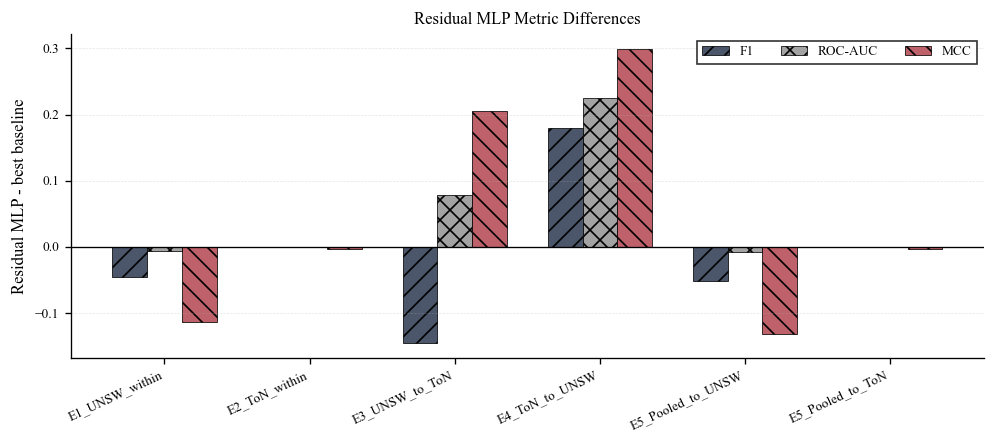

Residual MLP diagnostics


,protocol,test_name,best_baseline,baseline_f1,residual_mlp_f1,delta_f1,baseline_roc_auc,residual_mlp_roc_auc,delta_roc_auc,baseline_mcc,residual_mlp_mcc,delta_mcc,residual_mlp_fpr,residual_mlp_fnr,residual_mlp_precision,residual_mlp_recall,note
0,E1_UNSW_within,UNSW test,XGBoost,0.924482,0.879418,-0.045064,0.980106,0.974105,-0.006001,0.830353,0.717251,-0.113102,0.293486,0.027221,0.802409,0.972779,baseline has higher F1
1,E2_ToN_within,ToN-IoT test,LightGBM,0.997538,0.996934,-0.000604,0.999710,0.999412,-0.000298,0.988913,0.986117,-0.002796,0.010347,0.003200,0.997069,0.996800,baseline has higher F1
2,E3_UNSW_to_ToN,ToN-IoT test,XGBoost,0.560954,0.416053,-0.144901,0.133771,0.211682,0.077911,-0.366778,-0.161330,0.205448,0.482755,0.701418,0.685909,0.298582,mixed result
3,E4_ToN_to_UNSW,UNSW test,LightGBM,0.498965,0.678033,0.179068,0.293473,0.518654,0.225181,-0.320978,-0.021631,0.299347,0.904892,0.108290,0.546966,0.891710,MLP improves F1 and MCC
4,E5_Pooled_to_UNSW,UNSW test,LightGBM,0.929659,0.877785,-0.051874,0.980942,0.973193,-0.007749,0.844673,0.713644,-0.131029,0.306027,0.022434,0.796488,0.977566,baseline has higher F1
5,E5_Pooled_to_ToN,ToN-IoT test,Random Forest,0.997269,0.996664,-0.000605,0.999711,0.999251,-0.000460,0.987668,0.984903,-0.002765,0.010704,0.003638,0.996967,0.996362,baseline has higher F1



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\residual_mlp_diagnostics.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\residual_mlp\residual_mlp_metric_differences.pdf


In [7]:
best_baselines = pd.read_csv(TABLE_DIR / "best_baselines.csv")
mlp_test_results = pd.read_csv(TABLE_DIR / "residual_mlp_test_results.csv")
mlp_comparison = pd.read_csv(TABLE_DIR / "residual_mlp_vs_baseline.csv")


diagnostic_rows = []

for _, row in mlp_comparison.iterrows():
    protocol_name = row["protocol"]

    mlp_row = mlp_test_results[
        mlp_test_results["protocol"] == protocol_name
    ].iloc[0]

    baseline_row = best_baselines[
        best_baselines["protocol"] == protocol_name
    ].iloc[0]

    diagnostic_rows.append({
        "protocol": protocol_name,
        "test_name": row["test_name"],
        "best_baseline": row["best_baseline"],
        "baseline_f1": baseline_row["f1"],
        "residual_mlp_f1": mlp_row["f1"],
        "delta_f1": mlp_row["f1"] - baseline_row["f1"],
        "baseline_roc_auc": baseline_row["roc_auc"],
        "residual_mlp_roc_auc": mlp_row["roc_auc"],
        "delta_roc_auc": mlp_row["roc_auc"] - baseline_row["roc_auc"],
        "baseline_mcc": baseline_row["mcc"],
        "residual_mlp_mcc": mlp_row["mcc"],
        "delta_mcc": mlp_row["mcc"] - baseline_row["mcc"],
        "residual_mlp_fpr": mlp_row["fpr"],
        "residual_mlp_fnr": mlp_row["fnr"],
        "residual_mlp_precision": mlp_row["precision"],
        "residual_mlp_recall": mlp_row["recall"],
    })

mlp_diagnostics = pd.DataFrame(diagnostic_rows)


def result_note(row):
    if row["delta_f1"] > 0 and row["delta_mcc"] > 0:
        return "MLP improves F1 and MCC"
    if row["delta_f1"] > 0 and row["delta_roc_auc"] < 0:
        return "MLP improves F1 but not ranking"
    if row["delta_f1"] < 0 and row["delta_mcc"] > 0:
        return "mixed result"
    if row["delta_f1"] < 0:
        return "baseline has higher F1"
    return "similar performance"


mlp_diagnostics["note"] = mlp_diagnostics.apply(result_note, axis=1)

mlp_diagnostics.to_csv(TABLE_DIR / "residual_mlp_diagnostics.csv", index=False)


plot_df = mlp_diagnostics.copy()

protocol_order = [
    "E1_UNSW_within",
    "E2_ToN_within",
    "E3_UNSW_to_ToN",
    "E4_ToN_to_UNSW",
    "E5_Pooled_to_UNSW",
    "E5_Pooled_to_ToN",
]

plot_df = plot_df.set_index("protocol").loc[protocol_order].reset_index()

x = np.arange(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(8.4, 3.8))

ax.axhline(0, color="black", linewidth=0.8)

ax.bar(
    x - width,
    plot_df["delta_f1"],
    width,
    label="F1",
    color="#4C566A",
    edgecolor="black",
    linewidth=0.45,
    hatch="//",
)

ax.bar(
    x,
    plot_df["delta_roc_auc"],
    width,
    label="ROC-AUC",
    color="#A3A3A3",
    edgecolor="black",
    linewidth=0.45,
    hatch="xx",
)

ax.bar(
    x + width,
    plot_df["delta_mcc"],
    width,
    label="MCC",
    color="#BF616A",
    edgecolor="black",
    linewidth=0.45,
    hatch="\\\\",
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["protocol"], rotation=25, ha="right")
ax.set_ylabel("Residual MLP - best baseline")
ax.set_title("Residual MLP Metric Differences")
ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, edgecolor="black", fancybox=False, ncol=3)

plt.tight_layout()

diagnostic_pdf = MLP_FIG_DIR / "residual_mlp_metric_differences.pdf"
diagnostic_png = MLP_FIG_DIR / "residual_mlp_metric_differences.png"

plt.savefig(diagnostic_pdf, bbox_inches="tight")
plt.savefig(diagnostic_png, bbox_inches="tight")
plt.show()


print("Residual MLP diagnostics")
display(mlp_diagnostics)

print("\nSaved files")
print(f"- {TABLE_DIR / 'residual_mlp_diagnostics.csv'}")
print(f"- {diagnostic_pdf}")

## 8. Domain-adversarial MLP

Train a residual MLP with a domain classifier and gradient reversal to evaluate cross-dataset adaptation.

Device: cuda

DANN_UNSW_to_ToN
epoch=01 loss=0.3089 label=0.1694 domain=0.6974 val_f1=0.9486 val_auc=0.9750 domain_acc=0.4541 threshold=0.39
epoch=05 loss=0.2754 label=0.1096 domain=0.8289 val_f1=0.9531 val_auc=0.9814 domain_acc=0.5183 threshold=0.10
epoch=10 loss=0.2657 label=0.1076 domain=0.7904 val_f1=0.9528 val_auc=0.9809 domain_acc=0.2193 threshold=0.26
epoch=15 loss=0.2348 label=0.1031 domain=0.6583 val_f1=0.9541 val_auc=0.9832 domain_acc=0.2811 threshold=0.39
best_epoch=9 threshold=0.39 test_f1=0.8073 test_auc=0.3513 time=201.1s

DANN_ToN_to_UNSW
epoch=01 loss=0.2189 label=0.0614 domain=0.7874 val_f1=0.9896 val_auc=0.9956 domain_acc=0.2832 threshold=0.17
epoch=05 loss=0.1721 label=0.0250 domain=0.7356 val_f1=0.9920 val_auc=0.9982 domain_acc=0.4037 threshold=0.05
epoch=10 loss=0.1835 label=0.0275 domain=0.7799 val_f1=0.9920 val_auc=0.9976 domain_acc=0.3334 threshold=0.08
epoch=15 loss=0.1652 label=0.0212 domain=0.7200 val_f1=0.9920 val_auc=0.9979 domain_acc=0.3178 threshold=0.05


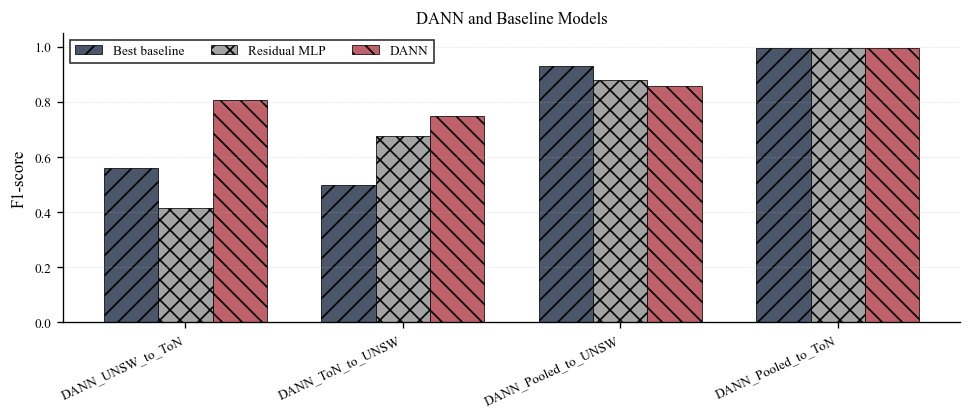


DANN test results


,protocol,model,test_name,target_supervised,test_rows,input_dim,threshold,threshold_source,validation_domain_accuracy,best_epoch,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,fpr,fnr
0,DANN_UNSW_to_ToN,DANN,ToN-IoT test,False,38095,187,0.390,source_validation,0.528388,9,0.677359,0.436817,0.755013,0.867450,0.807336,0.351310,0.674803,-0.171201,0.993815,0.132550
1,DANN_ToN_to_UNSW,DANN,UNSW test,False,82332,187,0.235,source_validation,0.479334,27,0.647719,0.613630,0.616886,0.950476,0.748181,0.571063,0.553908,0.315170,0.723216,0.049524
2,DANN_Pooled_to_UNSW,DANN,UNSW test,True,82332,187,0.295,unsw_validation,0.479334,10,0.819001,0.799893,0.756967,0.988706,0.857454,0.968163,0.976123,0.663880,0.388919,0.011294
3,DANN_Pooled_to_ToN,DANN,ToN-IoT test,True,38095,187,0.315,ton_validation,0.480031,22,0.993674,0.990954,0.996058,0.995823,0.995941,0.998997,0.999355,0.981615,0.013915,0.004177



DANN comparison


,dann_protocol,baseline_protocol,test_name,best_baseline,baseline_f1,residual_mlp_f1,dann_f1,dann_minus_baseline_f1,dann_minus_residual_mlp_f1,baseline_roc_auc,residual_mlp_roc_auc,dann_roc_auc,dann_minus_baseline_roc_auc,dann_minus_residual_mlp_roc_auc,baseline_mcc,residual_mlp_mcc,dann_mcc,dann_minus_baseline_mcc,dann_minus_residual_mlp_mcc
0,DANN_UNSW_to_ToN,E3_UNSW_to_ToN,ToN-IoT test,XGBoost,0.560954,0.416053,0.807336,0.246382,0.391283,0.133771,0.211682,0.351310,0.217539,0.139628,-0.366778,-0.161330,-0.171201,0.195577,-0.009871
1,DANN_ToN_to_UNSW,E4_ToN_to_UNSW,UNSW test,LightGBM,0.498965,0.678033,0.748181,0.249216,0.070148,0.293473,0.518654,0.571063,0.277590,0.052409,-0.320978,-0.021631,0.315170,0.636148,0.336801
2,DANN_Pooled_to_UNSW,E5_Pooled_to_UNSW,UNSW test,LightGBM,0.929659,0.877785,0.857454,-0.072205,-0.020331,0.980942,0.973193,0.968163,-0.012779,-0.005030,0.844673,0.713644,0.663880,-0.180793,-0.049764
3,DANN_Pooled_to_ToN,E5_Pooled_to_ToN,ToN-IoT test,Random Forest,0.997269,0.996664,0.995941,-0.001328,-0.000723,0.999711,0.999251,0.998997,-0.000714,-0.000254,0.987668,0.984903,0.981615,-0.006053,-0.003288



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\dann_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\dann_test_results.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\dann_history.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\dann_comparison.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\dann\dann_comparison.pdf
- models saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\dann
- figures saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\dann


In [8]:
import copy
import time
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


DANN_MODEL_DIR = MODEL_DIR / "dann"
DANN_FIG_DIR = FIG_DIR / "dann"

DANN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
DANN_FIG_DIR.mkdir(parents=True, exist_ok=True)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

print(f"Device: {DEVICE}")


try:
    unsw_train_split
    unsw_val_split
    unsw_test_split
    ton_train_split
    ton_val_split
    ton_test_split
except NameError:
    unsw_train_split = pd.read_parquet(OUT_DIR / "unsw_train_split.parquet")
    unsw_val_split = pd.read_parquet(OUT_DIR / "unsw_val_split.parquet")
    unsw_test_split = pd.read_parquet(OUT_DIR / "unsw_test_split.parquet")

    ton_train_split = pd.read_parquet(OUT_DIR / "ton_train_split.parquet")
    ton_val_split = pd.read_parquet(OUT_DIR / "ton_val_split.parquet")
    ton_test_split = pd.read_parquet(OUT_DIR / "ton_test_split.parquet")


with open(OUT_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

numeric_features = feature_info["numeric_features"]
categorical_features = feature_info["categorical_features"]
model_features = feature_info["model_features"]


if "build_preprocessor" not in globals():

    def signed_log1p_array(x):
        x = np.asarray(x, dtype=np.float64)
        return np.sign(x) * np.log1p(np.abs(x))


    def build_preprocessor():
        numeric_pipe = Pipeline(steps=[
            ("signed_log1p", FunctionTransformer(
                signed_log1p_array,
                feature_names_out="one-to-one",
            )),
            ("scaler", StandardScaler()),
        ])

        categorical_pipe = Pipeline(steps=[
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            )),
        ])

        return ColumnTransformer(
            transformers=[
                ("num", numeric_pipe, numeric_features),
                ("cat", categorical_pipe, categorical_features),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )


if "evaluate_binary" not in globals():

    def evaluate_binary(y_true, y_score, threshold=0.5):
        y_pred = (y_score >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        try:
            roc_auc = roc_auc_score(y_true, y_score)
        except Exception:
            roc_auc = np.nan

        try:
            pr_auc = average_precision_score(y_true, y_score)
        except Exception:
            pr_auc = np.nan

        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "mcc": matthews_corrcoef(y_true, y_pred),
            "fpr": fp / (fp + tn + 1e-9),
            "fnr": fn / (fn + tp + 1e-9),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }


if "clean_name" not in globals():

    def clean_name(text):
        return (
            str(text)
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
            .replace("/", "_")
        )


def get_xy(df):
    return df[model_features].copy(), df["label"].astype(int).values


def best_threshold(y_true, y_score):
    thresholds = np.linspace(0.05, 0.95, 181)

    scores = [
        f1_score(y_true, (y_score >= threshold).astype(int), zero_division=0)
        for threshold in thresholds
    ]

    best_idx = int(np.argmax(scores))

    return float(thresholds[best_idx]), float(scores[best_idx])


def make_dann_loader(x, y, domain, label_mask, batch_size=4096, shuffle=False, drop_last=False):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    d_tensor = torch.tensor(domain, dtype=torch.float32).view(-1, 1)
    m_tensor = torch.tensor(label_mask, dtype=torch.float32).view(-1, 1)

    dataset = TensorDataset(x_tensor, y_tensor, d_tensor, m_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


def make_dann_eval_loader(x, y, batch_size=4096):
    domain = np.zeros(len(y), dtype=np.float32)
    mask = np.ones(len(y), dtype=np.float32)

    return make_dann_loader(
        x=x,
        y=y,
        domain=domain,
        label_mask=mask,
        batch_size=batch_size,
        shuffle=False,
    )


class GradientReverseFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReverse(nn.Module):
    def forward(self, x, lambd=1.0):
        return GradientReverseFunction.apply(x, lambd)


class DANNResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.15):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
        )

        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.layers(x))


class DomainAdversarialMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, n_blocks=3, dropout=0.15):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            *[
                DANNResidualBlock(hidden_dim, dropout=dropout)
                for _ in range(n_blocks)
            ],
        )

        self.label_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

        self.grl = GradientReverse()

        self.domain_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, grl_lambda=1.0):
        features = self.encoder(x)

        label_logits = self.label_head(features)

        reversed_features = self.grl(features, grl_lambda)
        domain_logits = self.domain_head(reversed_features)

        return label_logits, domain_logits


def predict_dann(model, loader):
    model.eval()

    label_scores = []
    domain_scores = []

    with torch.no_grad():
        for xb, _, _, _ in loader:
            xb = xb.to(DEVICE)

            label_logits, domain_logits = model(xb, grl_lambda=0.0)

            label_scores.append(torch.sigmoid(label_logits).cpu().numpy().ravel())
            domain_scores.append(torch.sigmoid(domain_logits).cpu().numpy().ravel())

    return np.concatenate(label_scores), np.concatenate(domain_scores)


def get_domain_accuracy(model, x_source, x_target, batch_size=4096):
    x_all = np.vstack([x_source, x_target])

    y_dummy = np.zeros(len(x_all), dtype=np.float32)

    domain = np.concatenate([
        np.zeros(len(x_source), dtype=np.float32),
        np.ones(len(x_target), dtype=np.float32),
    ])

    mask = np.zeros(len(x_all), dtype=np.float32)

    loader = make_dann_loader(
        x=x_all,
        y=y_dummy,
        domain=domain,
        label_mask=mask,
        batch_size=batch_size,
        shuffle=False,
    )

    _, domain_score = predict_dann(model, loader)
    domain_pred = (domain_score >= 0.5).astype(int)

    return accuracy_score(domain.astype(int), domain_pred)


def grl_lambda(epoch, max_epochs):
    progress = epoch / max_epochs
    return float(2.0 / (1.0 + np.exp(-10.0 * progress)) - 1.0)


def plot_dann_history(history, protocol_name):
    fig, ax = plt.subplots(figsize=(5.8, 3.2))

    ax.plot(
        history["epoch"],
        history["val_f1"],
        marker="o",
        markersize=3,
        label="Validation F1",
        color="#4C566A",
    )

    ax.plot(
        history["epoch"],
        history["val_roc_auc"],
        marker="s",
        markersize=3,
        label="Validation ROC-AUC",
        color="#BF616A",
    )

    ax.plot(
        history["epoch"],
        history["val_domain_accuracy"],
        marker="^",
        markersize=3,
        label="Domain accuracy",
        color="#8F8F8F",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Training Curve: {protocol_name}")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, edgecolor="black", fancybox=False)

    plt.tight_layout()

    save_name = f"training_curve_{clean_name(protocol_name)}"
    pdf_path = DANN_FIG_DIR / f"{save_name}.pdf"
    png_path = DANN_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return pdf_path, png_path


def train_dann(
    protocol_name,
    source_train_df,
    target_train_df,
    source_val_df,
    target_val_df,
    test_df,
    test_name,
    target_supervised=False,
    max_epochs=30,
    batch_size=4096,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=6,
    domain_loss_weight=0.20,
):
    print(f"\n{protocol_name}")

    fit_df = pd.concat([source_train_df, target_train_df], ignore_index=True)

    preprocessor = build_preprocessor()
    preprocessor.fit(fit_df[model_features])

    x_source_train = preprocessor.transform(source_train_df[model_features]).astype(np.float32)
    y_source_train = source_train_df["label"].astype(int).values

    x_target_train = preprocessor.transform(target_train_df[model_features]).astype(np.float32)
    y_target_train = target_train_df["label"].astype(int).values

    x_source_val = preprocessor.transform(source_val_df[model_features]).astype(np.float32)
    y_source_val = source_val_df["label"].astype(int).values

    x_target_val = preprocessor.transform(target_val_df[model_features]).astype(np.float32)
    y_target_val = target_val_df["label"].astype(int).values

    x_test = preprocessor.transform(test_df[model_features]).astype(np.float32)
    y_test = test_df["label"].astype(int).values

    x_train = np.vstack([x_source_train, x_target_train])
    y_train = np.concatenate([y_source_train, y_target_train])

    domain_train = np.concatenate([
        np.zeros(len(x_source_train), dtype=np.float32),
        np.ones(len(x_target_train), dtype=np.float32),
    ])

    if target_supervised:
        label_mask = np.ones(len(x_train), dtype=np.float32)

        val_df = pd.concat([source_val_df, target_val_df], ignore_index=True)
        x_val = preprocessor.transform(val_df[model_features]).astype(np.float32)
        y_val = val_df["label"].astype(int).values
    else:
        label_mask = np.concatenate([
            np.ones(len(x_source_train), dtype=np.float32),
            np.zeros(len(x_target_train), dtype=np.float32),
        ])

        x_val = x_source_val
        y_val = y_source_val

    labelled_y = y_train[label_mask == 1]

    n_pos = np.sum(labelled_y == 1)
    n_neg = np.sum(labelled_y == 0)
    pos_weight = float(n_neg / max(n_pos, 1))

    input_dim = x_train.shape[1]

    train_loader = make_dann_loader(
        x=x_train,
        y=y_train,
        domain=domain_train,
        label_mask=label_mask,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
    )

    val_loader = make_dann_eval_loader(x_val, y_val, batch_size=batch_size)
    test_loader = make_dann_eval_loader(x_test, y_test, batch_size=batch_size)

    model = DomainAdversarialMLP(
        input_dim=input_dim,
        hidden_dim=128,
        n_blocks=3,
        dropout=0.15,
    ).to(DEVICE)

    label_loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE),
        reduction="none",
    )

    domain_loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    history = []
    best_state = None
    best_val_f1 = -1.0
    patience_count = 0

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()

        losses = []
        label_losses = []
        domain_losses = []

        current_lambda = grl_lambda(epoch, max_epochs)

        for xb, yb, db, mb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            db = db.to(DEVICE)
            mb = mb.to(DEVICE)

            optimizer.zero_grad()

            label_logits, domain_logits = model(xb, grl_lambda=current_lambda)

            raw_label_loss = label_loss_fn(label_logits, yb)
            label_loss = (raw_label_loss * mb).sum() / torch.clamp(mb.sum(), min=1.0)

            domain_loss = domain_loss_fn(domain_logits, db)

            loss = label_loss + domain_loss_weight * domain_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()

            losses.append(loss.item())
            label_losses.append(label_loss.item())
            domain_losses.append(domain_loss.item())

        val_score, _ = predict_dann(model, val_loader)
        threshold, val_f1 = best_threshold(y_val, val_score)
        val_metrics = evaluate_binary(y_val, val_score, threshold=threshold)

        val_domain_accuracy = get_domain_accuracy(
            model,
            x_source_val,
            x_target_val,
            batch_size=batch_size,
        )

        scheduler.step(val_f1)

        history.append({
            "protocol": protocol_name,
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "label_loss": float(np.mean(label_losses)),
            "domain_loss": float(np.mean(domain_losses)),
            "grl_lambda": current_lambda,
            "threshold": threshold,
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_mcc": val_metrics["mcc"],
            "val_domain_accuracy": val_domain_accuracy,
            "learning_rate": optimizer.param_groups[0]["lr"],
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_count = 0

            best_state = {
                "model_state": copy.deepcopy(model.state_dict()),
                "threshold": threshold,
                "val_f1": val_f1,
                "epoch": epoch,
            }
        else:
            patience_count += 1

        if epoch == 1 or epoch % 5 == 0 or patience_count >= patience:
            print(
                f"epoch={epoch:02d} "
                f"loss={np.mean(losses):.4f} "
                f"label={np.mean(label_losses):.4f} "
                f"domain={np.mean(domain_losses):.4f} "
                f"val_f1={val_metrics['f1']:.4f} "
                f"val_auc={val_metrics['roc_auc']:.4f} "
                f"domain_acc={val_domain_accuracy:.4f} "
                f"threshold={threshold:.2f}"
            )

        if patience_count >= patience:
            break

    train_time = time.time() - start_time

    model.load_state_dict(best_state["model_state"])

    history_df = pd.DataFrame(history)
    curve_pdf, curve_png = plot_dann_history(history_df, protocol_name)

    source_val_loader = make_dann_eval_loader(x_source_val, y_source_val, batch_size=batch_size)
    target_val_loader = make_dann_eval_loader(x_target_val, y_target_val, batch_size=batch_size)

    source_val_score, _ = predict_dann(model, source_val_loader)
    target_val_score, _ = predict_dann(model, target_val_loader)

    source_threshold, source_val_f1 = best_threshold(y_source_val, source_val_score)
    target_threshold, target_val_f1 = best_threshold(y_target_val, target_val_score)

    if target_supervised:
        if test_df["dataset"].iloc[0] == "UNSW-NB15":
            eval_threshold = source_threshold
            threshold_source = "unsw_validation"
        else:
            eval_threshold = target_threshold
            threshold_source = "ton_validation"
    else:
        eval_threshold = float(best_state["threshold"])
        threshold_source = "source_validation"

    test_score, test_domain_score = predict_dann(model, test_loader)
    test_metrics = evaluate_binary(y_test, test_score, threshold=eval_threshold)

    model_id = clean_name(protocol_name)

    model_path = DANN_MODEL_DIR / f"{model_id}.pt"
    preprocessor_path = DANN_MODEL_DIR / f"{model_id}_preprocessor.joblib"
    history_path = DANN_MODEL_DIR / f"{model_id}_history.csv"
    score_path = DANN_MODEL_DIR / f"{model_id}_test_scores.csv"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "input_dim": input_dim,
            "threshold": float(eval_threshold),
            "threshold_source": threshold_source,
            "source_validation_threshold": float(source_threshold),
            "target_validation_threshold": float(target_threshold),
            "feature_info": feature_info,
            "best_epoch": int(best_state["epoch"]),
            "best_val_f1": float(best_state["val_f1"]),
            "target_supervised": bool(target_supervised),
        },
        model_path,
    )

    joblib.dump(preprocessor, preprocessor_path)
    history_df.to_csv(history_path, index=False)

    score_df = test_df[["dataset", "split", "attack_type", "label"]].copy()
    score_df["score"] = test_score
    score_df["domain_score"] = test_domain_score
    score_df["threshold"] = eval_threshold
    score_df["prediction"] = (test_score >= eval_threshold).astype(int)
    score_df["correct"] = score_df["prediction"] == score_df["label"]
    score_df.to_csv(score_path, index=False)

    cm = np.array([
        [test_metrics["tn"], test_metrics["fp"]],
        [test_metrics["fn"], test_metrics["tp"]],
    ])

    cm_pdf, cm_png = plot_confusion_matrix(
        cm,
        title=f"DANN\n{protocol_name}",
        save_name=f"cm_{model_id}",
        save_dir=DANN_FIG_DIR,
    )

    result = {
        "protocol": protocol_name,
        "model": "DANN",
        "test_name": test_name,
        "target_supervised": target_supervised,
        "train_time_sec": round(train_time, 3),
        "input_dim": input_dim,
        "source_train_rows": len(source_train_df),
        "target_train_rows": len(target_train_df),
        "test_rows": len(test_df),
        "threshold": float(eval_threshold),
        "threshold_source": threshold_source,
        "source_validation_threshold": float(source_threshold),
        "target_validation_threshold": float(target_threshold),
        "source_validation_f1": float(source_val_f1),
        "target_validation_f1": float(target_val_f1),
        "best_epoch": int(best_state["epoch"]),
        "best_val_f1": float(best_state["val_f1"]),
        "validation_domain_accuracy": get_domain_accuracy(
            model,
            x_source_val,
            x_target_val,
            batch_size=batch_size,
        ),
        "model_path": str(model_path),
        "preprocessor_path": str(preprocessor_path),
        "history_path": str(history_path),
        "score_path": str(score_path),
        "training_curve_pdf": str(curve_pdf),
        "training_curve_png": str(curve_png),
        "confusion_pdf": str(cm_pdf),
        "confusion_png": str(cm_png),
    }

    result.update({
        key: round(value, 6) if isinstance(value, float) else value
        for key, value in test_metrics.items()
    })

    print(
        f"best_epoch={best_state['epoch']} "
        f"threshold={eval_threshold:.2f} "
        f"test_f1={test_metrics['f1']:.4f} "
        f"test_auc={test_metrics['roc_auc']:.4f} "
        f"time={train_time:.1f}s"
    )

    return result, history_df


dann_rows = []
dann_histories = []

settings = [
    {
        "protocol_name": "DANN_UNSW_to_ToN",
        "source_train_df": unsw_train_split,
        "target_train_df": ton_train_split,
        "source_val_df": unsw_val_split,
        "target_val_df": ton_val_split,
        "test_df": ton_test_split,
        "test_name": "ToN-IoT test",
        "target_supervised": False,
    },
    {
        "protocol_name": "DANN_ToN_to_UNSW",
        "source_train_df": ton_train_split,
        "target_train_df": unsw_train_split,
        "source_val_df": ton_val_split,
        "target_val_df": unsw_val_split,
        "test_df": unsw_test_split,
        "test_name": "UNSW test",
        "target_supervised": False,
    },
    {
        "protocol_name": "DANN_Pooled_to_UNSW",
        "source_train_df": unsw_train_split,
        "target_train_df": ton_train_split,
        "source_val_df": unsw_val_split,
        "target_val_df": ton_val_split,
        "test_df": unsw_test_split,
        "test_name": "UNSW test",
        "target_supervised": True,
    },
    {
        "protocol_name": "DANN_Pooled_to_ToN",
        "source_train_df": unsw_train_split,
        "target_train_df": ton_train_split,
        "source_val_df": unsw_val_split,
        "target_val_df": ton_val_split,
        "test_df": ton_test_split,
        "test_name": "ToN-IoT test",
        "target_supervised": True,
    },
]

for setting in settings:
    row, history = train_dann(
        **setting,
        max_epochs=30,
        batch_size=4096,
        patience=6,
        domain_loss_weight=0.20,
    )

    dann_rows.append(row)
    dann_histories.append(history)


dann_results = pd.DataFrame(dann_rows)
dann_history = pd.concat(dann_histories, ignore_index=True)

dann_results.to_csv(TABLE_DIR / "dann_results.csv", index=False)
dann_history.to_csv(TABLE_DIR / "dann_history.csv", index=False)

dann_test_results = dann_results[
    [
        "protocol",
        "model",
        "test_name",
        "target_supervised",
        "test_rows",
        "input_dim",
        "threshold",
        "threshold_source",
        "validation_domain_accuracy",
        "best_epoch",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "mcc",
        "fpr",
        "fnr",
    ]
].copy()

dann_test_results.to_csv(TABLE_DIR / "dann_test_results.csv", index=False)


best_baselines = pd.read_csv(TABLE_DIR / "best_baselines.csv")
mlp_test_results = pd.read_csv(TABLE_DIR / "residual_mlp_test_results.csv")

protocol_map = {
    "DANN_UNSW_to_ToN": "E3_UNSW_to_ToN",
    "DANN_ToN_to_UNSW": "E4_ToN_to_UNSW",
    "DANN_Pooled_to_UNSW": "E5_Pooled_to_UNSW",
    "DANN_Pooled_to_ToN": "E5_Pooled_to_ToN",
}

comparison_rows = []

for _, row in dann_test_results.iterrows():
    dann_protocol = row["protocol"]
    baseline_protocol = protocol_map[dann_protocol]

    baseline_row = best_baselines[
        best_baselines["protocol"] == baseline_protocol
    ].iloc[0]

    mlp_row = mlp_test_results[
        mlp_test_results["protocol"] == baseline_protocol
    ].iloc[0]

    comparison_rows.append({
        "dann_protocol": dann_protocol,
        "baseline_protocol": baseline_protocol,
        "test_name": row["test_name"],
        "best_baseline": baseline_row["model"],
        "baseline_f1": baseline_row["f1"],
        "residual_mlp_f1": mlp_row["f1"],
        "dann_f1": row["f1"],
        "dann_minus_baseline_f1": row["f1"] - baseline_row["f1"],
        "dann_minus_residual_mlp_f1": row["f1"] - mlp_row["f1"],
        "baseline_roc_auc": baseline_row["roc_auc"],
        "residual_mlp_roc_auc": mlp_row["roc_auc"],
        "dann_roc_auc": row["roc_auc"],
        "dann_minus_baseline_roc_auc": row["roc_auc"] - baseline_row["roc_auc"],
        "dann_minus_residual_mlp_roc_auc": row["roc_auc"] - mlp_row["roc_auc"],
        "baseline_mcc": baseline_row["mcc"],
        "residual_mlp_mcc": mlp_row["mcc"],
        "dann_mcc": row["mcc"],
        "dann_minus_baseline_mcc": row["mcc"] - baseline_row["mcc"],
        "dann_minus_residual_mlp_mcc": row["mcc"] - mlp_row["mcc"],
    })

dann_comparison = pd.DataFrame(comparison_rows)
dann_comparison.to_csv(TABLE_DIR / "dann_comparison.csv", index=False)


plot_df = dann_comparison.copy()

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(8.2, 3.6))

ax.bar(
    x - width,
    plot_df["baseline_f1"],
    width,
    label="Best baseline",
    color="#4C566A",
    edgecolor="black",
    linewidth=0.45,
    hatch="//",
)

ax.bar(
    x,
    plot_df["residual_mlp_f1"],
    width,
    label="Residual MLP",
    color="#A3A3A3",
    edgecolor="black",
    linewidth=0.45,
    hatch="xx",
)

ax.bar(
    x + width,
    plot_df["dann_f1"],
    width,
    label="DANN",
    color="#BF616A",
    edgecolor="black",
    linewidth=0.45,
    hatch="\\\\",
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["dann_protocol"], rotation=25, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("DANN and Baseline Models")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, edgecolor="black", fancybox=False, ncol=3)

plt.tight_layout()

comparison_pdf = DANN_FIG_DIR / "dann_comparison.pdf"
comparison_png = DANN_FIG_DIR / "dann_comparison.png"

plt.savefig(comparison_pdf, bbox_inches="tight")
plt.savefig(comparison_png, bbox_inches="tight")
plt.show()


print("\nDANN test results")
display(dann_test_results)

print("\nDANN comparison")
display(dann_comparison)

print("\nSaved files")
print(f"- {TABLE_DIR / 'dann_results.csv'}")
print(f"- {TABLE_DIR / 'dann_test_results.csv'}")
print(f"- {TABLE_DIR / 'dann_history.csv'}")
print(f"- {TABLE_DIR / 'dann_comparison.csv'}")
print(f"- {comparison_pdf}")
print(f"- models saved in {DANN_MODEL_DIR}")
print(f"- figures saved in {DANN_FIG_DIR}")

## 9. Model selection

Select the pooled detector used for SHAP explanations and summarize transfer results.

In [9]:
baseline_results = pd.read_csv(TABLE_DIR / "baseline_results.csv")
baseline_test_results = baseline_results[baseline_results["split"] == "test"].copy()

best_baselines = pd.read_csv(TABLE_DIR / "best_baselines.csv")
mlp_test_results = pd.read_csv(TABLE_DIR / "residual_mlp_test_results.csv")
dann_test_results = pd.read_csv(TABLE_DIR / "dann_test_results.csv")


pooled_protocols = ["E5_Pooled_to_UNSW", "E5_Pooled_to_ToN"]

pooled_candidates = baseline_test_results[
    baseline_test_results["protocol"].isin(pooled_protocols)
].copy()

pooled_candidates = pooled_candidates.sort_values(
    ["test_name", "f1", "roc_auc", "mcc"],
    ascending=[True, False, False, False],
)

best_pooled_models = (
    pooled_candidates
    .groupby("test_name", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_pooled_models.to_csv(TABLE_DIR / "best_pooled_models.csv", index=False)


selected_detector = baseline_test_results[
    (
        (baseline_test_results["protocol"] == "E5_Pooled_to_UNSW")
        & (baseline_test_results["model"] == "LightGBM")
    )
    |
    (
        (baseline_test_results["protocol"] == "E5_Pooled_to_ToN")
        & (baseline_test_results["model"] == "LightGBM")
    )
].copy()

selected_detector = selected_detector.sort_values(
    ["protocol", "test_name"]
).reset_index(drop=True)

selected_detector["use_for_shap"] = True

selected_detector.to_csv(TABLE_DIR / "selected_detector.csv", index=False)


transfer_rows = []

transfer_pairs = [
    ("UNSW_to_ToN", "E3_UNSW_to_ToN", "DANN_UNSW_to_ToN"),
    ("ToN_to_UNSW", "E4_ToN_to_UNSW", "DANN_ToN_to_UNSW"),
]

for setting_name, baseline_protocol, dann_protocol in transfer_pairs:
    baseline_row = best_baselines[
        best_baselines["protocol"] == baseline_protocol
    ].iloc[0]

    mlp_row = mlp_test_results[
        mlp_test_results["protocol"] == baseline_protocol
    ].iloc[0]

    dann_row = dann_test_results[
        dann_test_results["protocol"] == dann_protocol
    ].iloc[0]

    transfer_rows.append({
        "setting": setting_name,
        "baseline_protocol": baseline_protocol,
        "dann_protocol": dann_protocol,
        "best_baseline": baseline_row["model"],
        "baseline_f1": baseline_row["f1"],
        "residual_mlp_f1": mlp_row["f1"],
        "dann_f1": dann_row["f1"],
        "baseline_roc_auc": baseline_row["roc_auc"],
        "residual_mlp_roc_auc": mlp_row["roc_auc"],
        "dann_roc_auc": dann_row["roc_auc"],
        "baseline_mcc": baseline_row["mcc"],
        "residual_mlp_mcc": mlp_row["mcc"],
        "dann_mcc": dann_row["mcc"],
        "baseline_fpr": baseline_row["fpr"],
        "residual_mlp_fpr": mlp_row["fpr"],
        "dann_fpr": dann_row["fpr"],
        "baseline_fnr": baseline_row["fnr"],
        "residual_mlp_fnr": mlp_row["fnr"],
        "dann_fnr": dann_row["fnr"],
    })

transfer_summary = pd.DataFrame(transfer_rows)
transfer_summary.to_csv(TABLE_DIR / "transfer_summary.csv", index=False)


selection_info = {
    "selected_detector": "LightGBM",
    "selected_protocols": selected_detector["protocol"].tolist(),
    "selection_reason": (
        "LightGBM is used for SHAP analysis because it gives the strongest pooled UNSW result "
        "and near-best pooled ToN-IoT result while supporting fast tree-based SHAP explanations."
    ),
    "selected_detector_table": str(TABLE_DIR / "selected_detector.csv"),
    "transfer_summary_table": str(TABLE_DIR / "transfer_summary.csv"),
}

with open(OUT_DIR / "model_selection.json", "w", encoding="utf-8") as f:
    json.dump(selection_info, f, indent=4)


print("Best pooled models")
display(best_pooled_models[
    [
        "protocol",
        "model",
        "test_name",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "mcc",
        "fpr",
        "fnr",
        "model_path",
    ]
])

print("\nSelected detector")
display(selected_detector[
    [
        "protocol",
        "model",
        "test_name",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "mcc",
        "fpr",
        "fnr",
        "model_path",
    ]
])

print("\nTransfer summary")
display(transfer_summary)

print("\nSaved files")
print(f"- {TABLE_DIR / 'best_pooled_models.csv'}")
print(f"- {TABLE_DIR / 'selected_detector.csv'}")
print(f"- {TABLE_DIR / 'transfer_summary.csv'}")
print(f"- {OUT_DIR / 'model_selection.json'}")

Best pooled models


,protocol,model,test_name,accuracy,precision,recall,f1,roc_auc,mcc,fpr,fnr,model_path
0,E5_Pooled_to_ToN,Random Forest,ToN-IoT test,0.995747,0.998043,0.996497,0.997269,0.999711,0.987668,0.006898,0.003503,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\baselines\e5_pooled_to_ton__random_forest.joblib
1,E5_Pooled_to_UNSW,LightGBM,UNSW test,0.922995,0.935179,0.924204,0.929659,0.980942,0.844673,0.078486,0.075796,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\baselines\e5_pooled_to_unsw__lightgbm.joblib



Selected detector


,protocol,model,test_name,accuracy,precision,recall,f1,roc_auc,mcc,fpr,fnr,model_path
0,E5_Pooled_to_ToN,LightGBM,ToN-IoT test,0.995196,0.998311,0.995520,0.996914,0.999767,0.986104,0.005947,0.004480,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\baselines\e5_pooled_to_ton__lightgbm.joblib
1,E5_Pooled_to_UNSW,LightGBM,UNSW test,0.922995,0.935179,0.924204,0.929659,0.980942,0.844673,0.078486,0.075796,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\models\baselines\e5_pooled_to_unsw__lightgbm.joblib



Transfer summary


,setting,baseline_protocol,dann_protocol,best_baseline,baseline_f1,residual_mlp_f1,dann_f1,baseline_roc_auc,residual_mlp_roc_auc,dann_roc_auc,baseline_mcc,residual_mlp_mcc,dann_mcc,baseline_fpr,residual_mlp_fpr,dann_fpr,baseline_fnr,residual_mlp_fnr,dann_fnr
0,UNSW_to_ToN,E3_UNSW_to_ToN,DANN_UNSW_to_ToN,XGBoost,0.560954,0.416053,0.807336,0.133771,0.211682,0.351310,-0.366778,-0.161330,-0.171201,0.927450,0.482755,0.993815,0.507798,0.701418,0.132550
1,ToN_to_UNSW,E4_ToN_to_UNSW,DANN_ToN_to_UNSW,LightGBM,0.498965,0.678033,0.748181,0.293473,0.518654,0.571063,-0.320978,-0.021631,0.315170,0.862243,0.904892,0.723216,0.433645,0.108290,0.049524



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\best_pooled_models.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\selected_detector.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\transfer_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\model_selection.json


## 10. SHAP explanations

Compute global SHAP feature groups and case-level explanations for the selected LightGBM models.


E5_Pooled_to_ToN | LightGBM


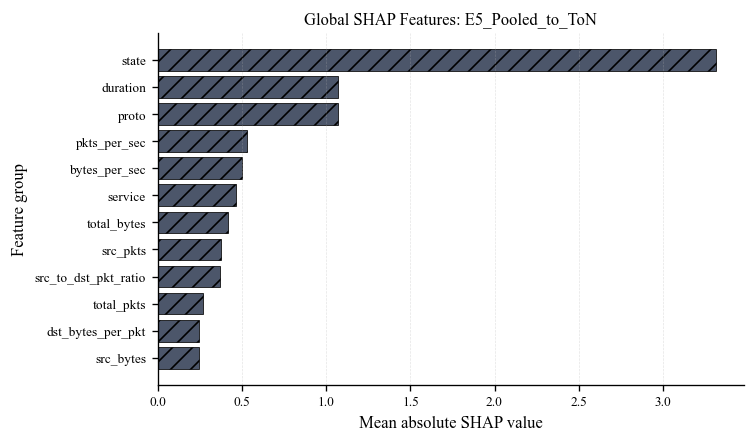

Top feature groups


,rank,feature_group,mean_abs_shap,mean_signed_shap,encoded_features
0,1,state,3.314966,0.599305,22
1,2,duration,1.070588,-0.144305,1
2,3,proto,1.067853,0.284808,133
3,4,pkts_per_sec,0.531887,0.108452,1
4,5,bytes_per_sec,0.499984,0.176481,1
5,6,service,0.463511,0.005926,17
6,7,total_bytes,0.416712,0.200048,1
7,8,src_pkts,0.373210,0.071158,1
8,9,src_to_dst_pkt_ratio,0.370969,-0.064209,1
9,10,total_pkts,0.265974,0.013973,1



E5_Pooled_to_UNSW | LightGBM


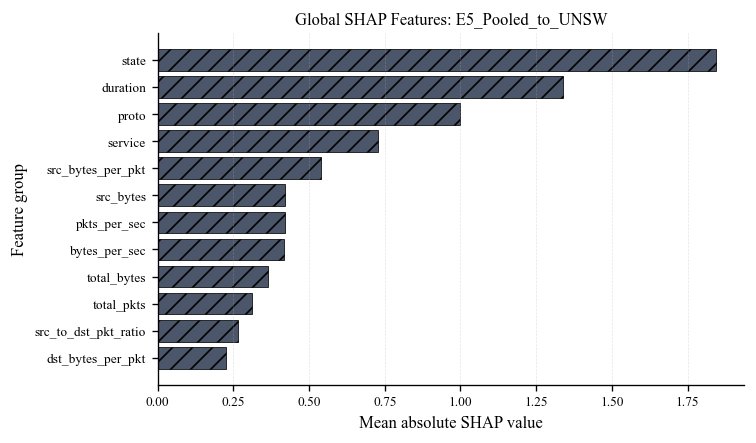

Top feature groups


,rank,feature_group,mean_abs_shap,mean_signed_shap,encoded_features
0,1,state,1.844170,-0.571546,22
1,2,duration,1.337425,-0.076517,1
2,3,proto,0.996764,-0.116324,133
3,4,service,0.727902,-0.153546,17
4,5,src_bytes_per_pkt,0.539368,-0.074099,1
5,6,src_bytes,0.420467,-0.253673,1
6,7,pkts_per_sec,0.420396,-0.022216,1
7,8,bytes_per_sec,0.415667,-0.126436,1
8,9,total_bytes,0.364608,-0.049616,1
9,10,total_pkts,0.311299,-0.034436,1



Top SHAP feature groups


,protocol,rank,feature_group,mean_abs_shap,mean_signed_shap,encoded_features
0,E5_Pooled_to_ToN,1,state,3.314966,0.599305,22
1,E5_Pooled_to_ToN,2,duration,1.070588,-0.144305,1
2,E5_Pooled_to_ToN,3,proto,1.067853,0.284808,133
3,E5_Pooled_to_ToN,4,pkts_per_sec,0.531887,0.108452,1
4,E5_Pooled_to_ToN,5,bytes_per_sec,0.499984,0.176481,1
5,E5_Pooled_to_ToN,6,service,0.463511,0.005926,17
6,E5_Pooled_to_ToN,7,total_bytes,0.416712,0.200048,1
7,E5_Pooled_to_ToN,8,src_pkts,0.373210,0.071158,1
8,E5_Pooled_to_UNSW,1,state,1.844170,-0.571546,22
9,E5_Pooled_to_UNSW,2,duration,1.337425,-0.076517,1



Detection by attack type


,protocol,attack_type,samples,metric,detection_rate,predicted_attack_percent,correct_percent
0,E5_Pooled_to_ToN,backdoor,3742,recall,0.999733,99.973276,99.973276
1,E5_Pooled_to_ToN,ddos,3999,recall,0.980495,98.049512,98.049512
2,E5_Pooled_to_ToN,dos,3799,recall,0.997368,99.736773,99.736773
3,E5_Pooled_to_ToN,injection,3993,recall,0.998247,99.824693,99.824693
4,E5_Pooled_to_ToN,mitm,208,recall,0.879808,87.980769,87.980769
5,E5_Pooled_to_ToN,normal,8408,specificity,0.994053,0.594672,99.405328
6,E5_Pooled_to_ToN,password,3972,recall,0.999245,99.924471,99.924471
7,E5_Pooled_to_ToN,ransomware,2947,recall,0.998303,99.830336,99.830336
8,E5_Pooled_to_ToN,scanning,4000,recall,0.999750,99.975000,99.975000
9,E5_Pooled_to_ToN,xss,3027,recall,0.999009,99.900892,99.900892



Case summary


,case_id,protocol,model,dataset,attack_type,true_label,predicted_label,score,threshold,case_type,top_evidence,top_shap,direction,evidence_csv,case_json,figure_pdf,figure_png
0,e5_pooled_to_ton_true_positive_37890,E5_Pooled_to_ToN,LightGBM,ToN-IoT,dos,1,1,0.999972,0.5,true_positive,state=REJ,4.963981,attack,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_true_positive_37890_eviden...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_true_positive_37890.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_true_positive_37890_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_true_positive_37890_shap.png
1,e5_pooled_to_ton_false_positive_3844,E5_Pooled_to_ToN,LightGBM,ToN-IoT,normal,0,1,0.999010,0.5,false_positive,duration=0.000000,2.154072,attack,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_false_positive_3844_eviden...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_false_positive_3844.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_false_positive_3844_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_false_positive_3844_shap.png
2,e5_pooled_to_ton_false_negative_7338,E5_Pooled_to_ToN,LightGBM,ToN-IoT,mitm,1,0,0.010269,0.5,false_negative,dst_bytes_per_pkt=103.0000,-1.391490,normal,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_false_negative_7338_eviden...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_false_negative_7338.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_false_negative_7338_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_false_negative_7338_shap.png
3,e5_pooled_to_ton_true_negative_9934,E5_Pooled_to_ToN,LightGBM,ToN-IoT,normal,0,0,0.000152,0.5,true_negative,state=S0,-2.519551,normal,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_true_negative_9934_evidenc...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_ton_true_negative_9934.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_true_negative_9934_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_ton_true_negative_9934_shap.png
4,e5_pooled_to_unsw_true_positive_5198,E5_Pooled_to_UNSW,LightGBM,UNSW-NB15,analysis,1,1,0.999899,0.5,true_positive,proto=unas,2.832604,attack,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_unsw_true_positive_5198_eviden...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_unsw_true_positive_5198.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_unsw_true_positive_5198_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_unsw_true_positive_5198_shap.png
5,e5_pooled_to_unsw_false_positive_42697,E5_Pooled_to_UNSW,LightGBM,UNSW-NB15,normal,0,1,0.996215,0.5,false_positive,duration=0.000009,1.920675,attack,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_unsw_false_positive_42697_evid...,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_unsw_false_positive_42697.json,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_unsw_false_positive_42697_shap.pdf,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap\e5_pooled_to_unsw_false_positive_42697_shap.png
6,e5_pooled_to_unsw_false_negative_11838,E5_Pooled_to_UNSW,LightGBM,UNSW-NB15,exploits,1,0,0.013351,0.5,false_negative,bytes_per_sec=279121.59,-2.182029,normal,F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\e5_pooled_to_unsw_false_negative_11838_evid...,F:\MBZUAI UAE\16-Conf


Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\shap\global_shap.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\shap\top_shap_features.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\shap\detection_by_attack_type.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\case_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\artifacts\case_explanations\case_details.json
- figures saved in F:\MBZUAI UAE\16-Conference\2-WiMob26\output\figures\shap


In [10]:
import joblib
import shap


SHAP_DIR = OUT_DIR / "shap"
SHAP_TABLE_DIR = TABLE_DIR / "shap"
SHAP_FIG_DIR = FIG_DIR / "shap"
CASE_DIR = ARTIFACT_DIR / "case_explanations"

for path in [SHAP_DIR, SHAP_TABLE_DIR, SHAP_FIG_DIR, CASE_DIR]:
    path.mkdir(parents=True, exist_ok=True)


selected_detector = pd.read_csv(TABLE_DIR / "selected_detector.csv")

try:
    unsw_test_split
    ton_test_split
except NameError:
    unsw_test_split = pd.read_parquet(OUT_DIR / "unsw_test_split.parquet")
    ton_test_split = pd.read_parquet(OUT_DIR / "ton_test_split.parquet")


with open(OUT_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

numeric_features = feature_info["numeric_features"]
categorical_features = feature_info["categorical_features"]
model_features = feature_info["model_features"]


def name_id(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )


def get_test_data(protocol):
    if protocol == "E5_Pooled_to_UNSW":
        return unsw_test_split.copy()

    if protocol == "E5_Pooled_to_ToN":
        return ton_test_split.copy()

    raise ValueError(f"Unknown protocol: {protocol}")


def feature_group(encoded_feature):
    if encoded_feature in numeric_features:
        return encoded_feature

    for col in categorical_features:
        prefix = f"{col}_"

        if encoded_feature.startswith(prefix):
            return col

    return encoded_feature


def shap_array(explainer, x):
    values = explainer.shap_values(x)

    if isinstance(values, list):
        values = values[1]

    values = np.asarray(values)

    if values.ndim == 3:
        values = values[:, :, 1]

    return values


def grouped_shap_table(values, feature_names):
    groups = [feature_group(feature) for feature in feature_names]
    rows = []

    for group in list(dict.fromkeys(groups)):
        idx = [i for i, item in enumerate(groups) if item == group]

        group_signed = values[:, idx].sum(axis=1)
        group_abs = np.abs(values[:, idx]).sum(axis=1)

        rows.append({
            "feature_group": group,
            "mean_abs_shap": float(group_abs.mean()),
            "mean_signed_shap": float(group_signed.mean()),
            "median_abs_shap": float(np.median(group_abs)),
            "max_abs_shap": float(group_abs.max()),
            "encoded_features": len(idx),
        })

    out = pd.DataFrame(rows)
    out = out.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)

    return out


def plot_global_shap(table, title, save_name, top_n=12):
    plot_df = table.head(top_n).copy()
    plot_df = plot_df.sort_values("mean_abs_shap", ascending=True)

    fig, ax = plt.subplots(figsize=(6.4, 3.8))

    ax.barh(
        plot_df["feature_group"],
        plot_df["mean_abs_shap"],
        color="#4C566A",
        edgecolor="black",
        linewidth=0.45,
        hatch="//",
    )

    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("Feature group")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    pdf_path = SHAP_FIG_DIR / f"{save_name}.pdf"
    png_path = SHAP_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.show()

    return pdf_path, png_path


def raw_evidence_text(encoded_feature, raw_row):
    if encoded_feature in numeric_features:
        value = raw_row[encoded_feature]

        if pd.isna(value):
            return f"{encoded_feature}=missing", value

        value = float(value)

        if encoded_feature in ["pkts_per_sec", "bytes_per_sec"] and raw_row["duration"] < 1e-6:
            return f"{encoded_feature}={value:.4g} (duration near zero)", value

        if abs(value) >= 1000:
            return f"{encoded_feature}={value:.2f}", value

        if abs(value) >= 1:
            return f"{encoded_feature}={value:.4f}", value

        return f"{encoded_feature}={value:.6f}", value

    for col in categorical_features:
        prefix = f"{col}_"

        if encoded_feature.startswith(prefix):
            category = encoded_feature[len(prefix):]
            return f"{col}={category}", raw_row[col]

    return encoded_feature, None


def local_evidence_table(shap_values, encoded_values, raw_row, feature_names, top_n=8):
    rows = []

    for idx, feature in enumerate(feature_names):
        encoded_value = float(encoded_values[idx])
        shap_value = float(shap_values[idx])

        if feature not in numeric_features and encoded_value < 0.5:
            continue

        evidence, raw_value = raw_evidence_text(feature, raw_row)

        rows.append({
            "encoded_feature": feature,
            "feature_group": feature_group(feature),
            "evidence": evidence,
            "raw_value": raw_value,
            "encoded_value": encoded_value,
            "shap_value": shap_value,
            "abs_shap_value": abs(shap_value),
            "direction": "attack" if shap_value > 0 else "normal",
        })

    out = pd.DataFrame(rows)

    if len(out) == 0:
        return out

    return out.sort_values("abs_shap_value", ascending=False).head(top_n).reset_index(drop=True)


def plot_local_evidence(table, title, save_name):
    if len(table) == 0:
        return None, None

    plot_df = table.copy()
    plot_df = plot_df.sort_values("abs_shap_value", ascending=True)

    colors = [
        "#BF616A" if value > 0 else "#4C566A"
        for value in plot_df["shap_value"]
    ]

    fig, ax = plt.subplots(figsize=(6.6, 3.8))

    ax.barh(
        plot_df["evidence"],
        plot_df["shap_value"],
        color=colors,
        edgecolor="black",
        linewidth=0.45,
    )

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value")
    ax.set_ylabel("Evidence")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    pdf_path = SHAP_FIG_DIR / f"{save_name}.pdf"
    png_path = SHAP_FIG_DIR / f"{save_name}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, bbox_inches="tight")
    plt.close()

    return pdf_path, png_path


def selected_cases(result_df):
    case_list = []

    groups = {
        "true_positive": result_df[(result_df["label"] == 1) & (result_df["prediction"] == 1)],
        "false_positive": result_df[(result_df["label"] == 0) & (result_df["prediction"] == 1)],
        "false_negative": result_df[(result_df["label"] == 1) & (result_df["prediction"] == 0)],
        "true_negative": result_df[(result_df["label"] == 0) & (result_df["prediction"] == 0)],
    }

    if len(groups["true_positive"]) > 0:
        idx = int(groups["true_positive"].sort_values("score", ascending=False).index[0])
        case_list.append(("true_positive", idx))

    if len(groups["false_positive"]) > 0:
        idx = int(groups["false_positive"].sort_values("score", ascending=False).index[0])
        case_list.append(("false_positive", idx))

    if len(groups["false_negative"]) > 0:
        idx = int(groups["false_negative"].sort_values("score", ascending=True).index[0])
        case_list.append(("false_negative", idx))

    if len(groups["true_negative"]) > 0:
        idx = int(groups["true_negative"].sort_values("score", ascending=True).index[0])
        case_list.append(("true_negative", idx))

    return case_list


def detection_by_attack_type(result_df, protocol):
    rows = []

    for attack_type, group in result_df.groupby("attack_type"):
        y_true = group["label"].astype(int).values
        y_pred = group["prediction"].astype(int).values

        if attack_type == "normal":
            metric_name = "specificity"
            detection_rate = float(np.mean(y_pred == 0))
        else:
            metric_name = "recall"
            detection_rate = float(np.mean(y_pred == 1))

        rows.append({
            "protocol": protocol,
            "attack_type": attack_type,
            "samples": len(group),
            "metric": metric_name,
            "detection_rate": detection_rate,
            "predicted_attack_percent": float(np.mean(y_pred) * 100),
            "correct_percent": float(np.mean(y_true == y_pred) * 100),
        })

    return pd.DataFrame(rows).sort_values(["protocol", "attack_type"]).reset_index(drop=True)


SHAP_SAMPLE_SIZE = 5000
THRESHOLD = 0.50

global_tables = []
detection_tables = []
case_rows = []
case_json = []

for _, detector in selected_detector.iterrows():
    protocol = detector["protocol"]
    model_name = detector["model"]
    model_path = detector["model_path"]

    print(f"\n{protocol} | {model_name}")

    test_df = get_test_data(protocol).reset_index(drop=True)
    pipeline = joblib.load(model_path)

    preprocessor = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]

    x_test = test_df[model_features].copy()
    y_test = test_df["label"].astype(int).values

    scores = pipeline.predict_proba(x_test)[:, 1]
    predictions = (scores >= THRESHOLD).astype(int)

    result_df = test_df[["dataset", "split", "attack_type", "label"]].copy()
    result_df["score"] = scores
    result_df["prediction"] = predictions
    result_df["correct"] = result_df["label"] == result_df["prediction"]

    stem = name_id(protocol)

    score_path = SHAP_DIR / f"{stem}_scores.csv"
    result_df.to_csv(score_path, index=False)

    detection_table = detection_by_attack_type(result_df, protocol)
    detection_tables.append(detection_table)

    detection_path = SHAP_TABLE_DIR / f"{stem}_detection_by_attack_type.csv"
    detection_table.to_csv(detection_path, index=False)

    sample_n = min(SHAP_SAMPLE_SIZE, len(test_df))

    sample_df = (
        test_df
        .assign(row_id=np.arange(len(test_df)))
        .groupby("label", group_keys=False)
        .apply(lambda g: g.sample(
            n=max(1, int(sample_n * len(g) / len(test_df))),
            random_state=SEED,
        ))
        .reset_index(drop=True)
    )

    if len(sample_df) < sample_n:
        used = set(sample_df["row_id"].tolist())
        remaining = test_df.assign(row_id=np.arange(len(test_df)))
        remaining = remaining[~remaining["row_id"].isin(used)]

        add_n = min(sample_n - len(sample_df), len(remaining))

        if add_n > 0:
            sample_df = pd.concat(
                [sample_df, remaining.sample(n=add_n, random_state=SEED)],
                ignore_index=True,
            )

    sample_df = sample_df.drop(columns=["row_id"])

    x_sample = sample_df[model_features].copy()
    x_encoded = preprocessor.transform(x_sample)
    feature_names = preprocessor.get_feature_names_out()

    x_encoded_df = pd.DataFrame(x_encoded, columns=feature_names)

    explainer = shap.TreeExplainer(model)
    values = shap_array(explainer, x_encoded_df)

    global_table = grouped_shap_table(values, feature_names)
    global_table["protocol"] = protocol
    global_table["model"] = model_name
    global_table["test_name"] = detector["test_name"]
    global_table["sample_size"] = len(sample_df)

    global_tables.append(global_table)

    global_path = SHAP_TABLE_DIR / f"{stem}_global_shap.csv"
    global_table.to_csv(global_path, index=False)

    plot_global_shap(
        table=global_table,
        title=f"Global SHAP Features: {protocol}",
        save_name=f"{stem}_global_shap",
        top_n=12,
    )

    print("Top feature groups")
    display(global_table[
        ["rank", "feature_group", "mean_abs_shap", "mean_signed_shap", "encoded_features"]
    ].head(12))

    for case_type, case_idx in selected_cases(result_df):
        raw_row = test_df.iloc[case_idx]
        case_raw = test_df.iloc[[case_idx]][model_features]

        case_encoded = preprocessor.transform(case_raw)
        case_encoded_df = pd.DataFrame(case_encoded, columns=feature_names)

        case_values = shap_array(explainer, case_encoded_df)[0]
        evidence = local_evidence_table(
            shap_values=case_values,
            encoded_values=case_encoded[0],
            raw_row=raw_row,
            feature_names=feature_names,
            top_n=8,
        )

        case_result = result_df.iloc[case_idx]
        case_id = f"{stem}_{case_type}_{case_idx}"

        evidence_path = CASE_DIR / f"{case_id}_evidence.csv"
        evidence.to_csv(evidence_path, index=False)

        local_pdf, local_png = plot_local_evidence(
            table=evidence,
            title=f"{case_type.replace('_', ' ').title()} | score={case_result['score']:.3f}",
            save_name=f"{case_id}_shap",
        )

        top_evidence = evidence[
            ["evidence", "feature_group", "shap_value", "direction"]
        ].to_dict(orient="records")

        case_record = {
            "case_id": case_id,
            "protocol": protocol,
            "model": model_name,
            "dataset": case_result["dataset"],
            "attack_type": case_result["attack_type"],
            "true_label": int(case_result["label"]),
            "predicted_label": int(case_result["prediction"]),
            "score": float(case_result["score"]),
            "threshold": THRESHOLD,
            "case_type": case_type,
            "top_evidence": top_evidence,
            "evidence_csv": str(evidence_path),
            "figure_pdf": str(local_pdf) if local_pdf else None,
            "figure_png": str(local_png) if local_png else None,
        }

        case_path = CASE_DIR / f"{case_id}.json"

        with open(case_path, "w", encoding="utf-8") as f:
            json.dump(case_record, f, indent=4)

        case_json.append(case_record)

        case_rows.append({
            "case_id": case_id,
            "protocol": protocol,
            "model": model_name,
            "dataset": case_result["dataset"],
            "attack_type": case_result["attack_type"],
            "true_label": int(case_result["label"]),
            "predicted_label": int(case_result["prediction"]),
            "score": float(case_result["score"]),
            "threshold": THRESHOLD,
            "case_type": case_type,
            "top_evidence": top_evidence[0]["evidence"] if len(top_evidence) else None,
            "top_shap": top_evidence[0]["shap_value"] if len(top_evidence) else None,
            "direction": top_evidence[0]["direction"] if len(top_evidence) else None,
            "evidence_csv": str(evidence_path),
            "case_json": str(case_path),
            "figure_pdf": str(local_pdf) if local_pdf else None,
            "figure_png": str(local_png) if local_png else None,
        })


global_shap = pd.concat(global_tables, ignore_index=True)
attack_detection = pd.concat(detection_tables, ignore_index=True)
case_summary = pd.DataFrame(case_rows)

top_shap = (
    global_shap
    .sort_values(["protocol", "mean_abs_shap"], ascending=[True, False])
    .groupby("protocol", as_index=False)
    .head(8)
    .reset_index(drop=True)
)

global_shap_path = SHAP_TABLE_DIR / "global_shap.csv"
top_shap_path = SHAP_TABLE_DIR / "top_shap_features.csv"
attack_detection_path = SHAP_TABLE_DIR / "detection_by_attack_type.csv"
case_summary_path = CASE_DIR / "case_summary.csv"
case_json_path = CASE_DIR / "case_details.json"

global_shap.to_csv(global_shap_path, index=False)
top_shap.to_csv(top_shap_path, index=False)
attack_detection.to_csv(attack_detection_path, index=False)
case_summary.to_csv(case_summary_path, index=False)

with open(case_json_path, "w", encoding="utf-8") as f:
    json.dump(case_json, f, indent=4)


print("\nTop SHAP feature groups")
display(top_shap[
    ["protocol", "rank", "feature_group", "mean_abs_shap", "mean_signed_shap", "encoded_features"]
])

print("\nDetection by attack type")
display(attack_detection)

print("\nCase summary")
display(case_summary)

print("\nSaved files")
print(f"- {global_shap_path}")
print(f"- {top_shap_path}")
print(f"- {attack_detection_path}")
print(f"- {case_summary_path}")
print(f"- {case_json_path}")
print(f"- figures saved in {SHAP_FIG_DIR}")

In [11]:
SUMMARY_DIR = TABLE_DIR / "summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


split_summary = pd.read_csv(TABLE_DIR / "split_summary.csv")
best_baselines = pd.read_csv(TABLE_DIR / "best_baselines.csv")
baseline_test_results = pd.read_csv(TABLE_DIR / "baseline_test_results.csv")
mlp_test_results = pd.read_csv(TABLE_DIR / "residual_mlp_test_results.csv")
dann_test_results = pd.read_csv(TABLE_DIR / "dann_test_results.csv")
selected_detector = pd.read_csv(TABLE_DIR / "selected_detector.csv")
transfer_summary = pd.read_csv(TABLE_DIR / "transfer_summary.csv")
top_shap = pd.read_csv(TABLE_DIR / "shap" / "top_shap_features.csv")
attack_detection = pd.read_csv(TABLE_DIR / "shap" / "detection_by_attack_type.csv")
case_summary = pd.read_csv(ARTIFACT_DIR / "case_explanations" / "case_summary.csv")


metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "mcc",
    "fpr",
    "fnr",
]


# Dataset and split summary
split_summary_compact = split_summary[
    [
        "split",
        "rows",
        "normal",
        "attack",
        "attack_percent",
        "attack_types",
        "datasets",
    ]
].copy()

split_summary_compact.to_csv(SUMMARY_DIR / "split_summary_compact.csv", index=False)


# Main model comparison
model_rows = []

for _, row in best_baselines.iterrows():
    model_rows.append({
        "setting": row["protocol"],
        "model_group": "Best baseline",
        "model": row["model"],
        "test_name": row["test_name"],
        **{col: row[col] for col in metric_cols},
    })

for _, row in mlp_test_results.iterrows():
    model_rows.append({
        "setting": row["protocol"],
        "model_group": "Residual MLP",
        "model": row["model"],
        "test_name": row["test_name"],
        **{col: row[col] for col in metric_cols},
    })

dann_setting_map = {
    "DANN_UNSW_to_ToN": "E3_UNSW_to_ToN",
    "DANN_ToN_to_UNSW": "E4_ToN_to_UNSW",
    "DANN_Pooled_to_UNSW": "E5_Pooled_to_UNSW",
    "DANN_Pooled_to_ToN": "E5_Pooled_to_ToN",
}

for _, row in dann_test_results.iterrows():
    model_rows.append({
        "setting": dann_setting_map[row["protocol"]],
        "model_group": "DANN",
        "model": row["model"],
        "test_name": row["test_name"],
        **{col: row[col] for col in metric_cols},
    })

model_results_summary = pd.DataFrame(model_rows)

setting_order = {
    "E1_UNSW_within": 1,
    "E2_ToN_within": 2,
    "E3_UNSW_to_ToN": 3,
    "E4_ToN_to_UNSW": 4,
    "E5_Pooled_to_UNSW": 5,
    "E5_Pooled_to_ToN": 6,
}

model_group_order = {
    "Best baseline": 1,
    "Residual MLP": 2,
    "DANN": 3,
}

model_results_summary["setting_order"] = model_results_summary["setting"].map(setting_order)
model_results_summary["model_group_order"] = model_results_summary["model_group"].map(model_group_order)

model_results_summary = (
    model_results_summary
    .sort_values(["setting_order", "model_group_order"])
    .drop(columns=["setting_order", "model_group_order"])
    .reset_index(drop=True)
)

model_results_summary.to_csv(SUMMARY_DIR / "model_results_summary.csv", index=False)


# Selected SHAP models
selected_detector_summary = selected_detector[
    [
        "protocol",
        "model",
        "test_name",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "mcc",
        "fpr",
        "fnr",
        "model_path",
    ]
].copy()

selected_detector_summary.to_csv(SUMMARY_DIR / "selected_detector_summary.csv", index=False)


# Cross-dataset transfer summary
transfer_summary_compact = transfer_summary[
    [
        "setting",
        "best_baseline",
        "baseline_f1",
        "residual_mlp_f1",
        "dann_f1",
        "baseline_roc_auc",
        "residual_mlp_roc_auc",
        "dann_roc_auc",
        "baseline_mcc",
        "residual_mlp_mcc",
        "dann_mcc",
        "baseline_fpr",
        "residual_mlp_fpr",
        "dann_fpr",
        "baseline_fnr",
        "residual_mlp_fnr",
        "dann_fnr",
    ]
].copy()

transfer_summary_compact.to_csv(SUMMARY_DIR / "transfer_summary_compact.csv", index=False)


# Top SHAP features
top_shap_summary = top_shap[
    [
        "protocol",
        "rank",
        "feature_group",
        "mean_abs_shap",
        "mean_signed_shap",
        "encoded_features",
    ]
].copy()

top_shap_summary.to_csv(SUMMARY_DIR / "top_shap_summary.csv", index=False)


# Harder attack types
attack_only = attack_detection[
    attack_detection["attack_type"] != "normal"
].copy()

hard_attack_types = (
    attack_only
    .sort_values(["protocol", "detection_rate"], ascending=[True, True])
    .groupby("protocol", as_index=False)
    .head(5)
    .reset_index(drop=True)
)

normal_specificity = attack_detection[
    attack_detection["attack_type"] == "normal"
].copy()

hard_attack_types.to_csv(SUMMARY_DIR / "low_detection_attack_types.csv", index=False)
normal_specificity.to_csv(SUMMARY_DIR / "normal_specificity.csv", index=False)


# Case-level explanations
case_summary_compact = case_summary[
    [
        "protocol",
        "dataset",
        "attack_type",
        "case_type",
        "true_label",
        "predicted_label",
        "score",
        "top_evidence",
        "top_shap",
        "direction",
    ]
].copy()

case_summary_compact.to_csv(SUMMARY_DIR / "case_summary_compact.csv", index=False)


summary_index = {
    "split_summary": str(SUMMARY_DIR / "split_summary_compact.csv"),
    "model_results": str(SUMMARY_DIR / "model_results_summary.csv"),
    "selected_detector": str(SUMMARY_DIR / "selected_detector_summary.csv"),
    "transfer_summary": str(SUMMARY_DIR / "transfer_summary_compact.csv"),
    "top_shap": str(SUMMARY_DIR / "top_shap_summary.csv"),
    "low_detection_attack_types": str(SUMMARY_DIR / "low_detection_attack_types.csv"),
    "normal_specificity": str(SUMMARY_DIR / "normal_specificity.csv"),
    "case_summary": str(SUMMARY_DIR / "case_summary_compact.csv"),
}

with open(SUMMARY_DIR / "summary_index.json", "w", encoding="utf-8") as f:
    json.dump(summary_index, f, indent=4)


print("Split summary")
display(split_summary_compact)

print("\nModel results")
display(model_results_summary)

print("\nSelected detector")
display(selected_detector_summary)

print("\nTransfer summary")
display(transfer_summary_compact)

print("\nTop SHAP features")
display(top_shap_summary)

print("\nLow detection attack types")
display(hard_attack_types)

print("\nCase summary")
display(case_summary_compact)

print("\nSaved files")
for _, path in summary_index.items():
    print(f"- {path}")

Split summary


,split,rows,normal,attack,attack_percent,attack_types,datasets
0,UNSW train,140272,44800,95472,68.062,10,UNSW-NB15
1,UNSW validation,35069,11200,23869,68.063,10,UNSW-NB15
2,UNSW test,82332,37000,45332,55.060,10,UNSW-NB15
3,ToN-IoT train,114284,25224,89060,77.929,10,ToN-IoT
4,ToN-IoT validation,38095,8408,29687,77.929,10,ToN-IoT
5,ToN-IoT test,38095,8408,29687,77.929,10,ToN-IoT
6,Pooled train,254556,70024,184532,72.492,17,"ToN-IoT, UNSW-NB15"
7,Pooled validation,73164,19608,53556,73.200,17,"ToN-IoT, UNSW-NB15"



Model results


,setting,model_group,model,test_name,accuracy,precision,recall,f1,roc_auc,mcc,fpr,fnr
0,E1_UNSW_within,Best baseline,XGBoost,UNSW test,0.916132,0.916752,0.932344,0.924482,0.980106,0.830353,0.103730,0.067656
1,E1_UNSW_within,Residual MLP,Residual MLP,UNSW test,0.853119,0.802409,0.972779,0.879418,0.974105,0.717251,0.293486,0.027221
2,E2_ToN_within,Best baseline,LightGBM,ToN-IoT test,0.996167,0.998852,0.996227,0.997538,0.999710,0.988913,0.004044,0.003773
3,E2_ToN_within,Residual MLP,Residual MLP,ToN-IoT test,0.995222,0.997069,0.996800,0.996934,0.999412,0.986117,0.010347,0.003200
4,E3_UNSW_to_ToN,Best baseline,XGBoost,ToN-IoT test,0.399580,0.652030,0.492202,0.560954,0.133771,-0.366778,0.927450,0.507798
5,E3_UNSW_to_ToN,Residual MLP,Residual MLP,ToN-IoT test,0.346843,0.685909,0.298582,0.416053,0.211682,-0.161330,0.482755,0.701418
6,E3_UNSW_to_ToN,DANN,DANN,ToN-IoT test,0.677359,0.755013,0.867450,0.807336,0.351310,-0.171201,0.993815,0.132550
7,E4_ToN_to_UNSW,Best baseline,LightGBM,UNSW test,0.373743,0.445907,0.566355,0.498965,0.293473,-0.320978,0.862243,0.433645
8,E4_ToN_to_UNSW,Residual MLP,Residual MLP,UNSW test,0.533717,0.546966,0.891710,0.678033,0.518654,-0.021631,0.904892,0.108290
9,E4_ToN_to_UNSW,DANN,DANN,UNSW test,0.647719,0.616886,0.950476,0.748181,0.571063,0.315170,0.723216,0.049524



Selected detector


...


Low detection attack types


,protocol,attack_type,samples,metric,detection_rate,predicted_attack_percent,correct_percent
0,E5_Pooled_to_ToN,mitm,208,recall,0.879808,87.980769,87.980769
1,E5_Pooled_to_ToN,ddos,3999,recall,0.980495,98.049512,98.049512
2,E5_Pooled_to_ToN,dos,3799,recall,0.997368,99.736773,99.736773
3,E5_Pooled_to_ToN,injection,3993,recall,0.998247,99.824693,99.824693
4,E5_Pooled_to_ToN,ransomware,2947,recall,0.998303,99.830336,99.830336
5,E5_Pooled_to_UNSW,fuzzers,6062,recall,0.568294,56.829429,56.829429
6,E5_Pooled_to_UNSW,shellcode,378,recall,0.708995,70.899471,70.899471
7,E5_Pooled_to_UNSW,worms,44,recall,0.954545,95.454545,95.454545
8,E5_Pooled_to_UNSW,exploits,11132,recall,0.960834,96.083363,96.083363
9,E5_Pooled_to_UNSW,dos,4089,recall,0.969675,96.967474,96.967474



Case summary


,protocol,dataset,attack_type,case_type,true_label,predicted_label,score,top_evidence,top_shap,direction
0,E5_Pooled_to_ToN,ToN-IoT,dos,true_positive,1,1,0.999972,state=REJ,4.963981,attack
1,E5_Pooled_to_ToN,ToN-IoT,normal,false_positive,0,1,0.999010,duration=0.000000,2.154072,attack
2,E5_Pooled_to_ToN,ToN-IoT,mitm,false_negative,1,0,0.010269,dst_bytes_per_pkt=103.0000,-1.391490,normal
3,E5_Pooled_to_ToN,ToN-IoT,normal,true_negative,0,0,0.000152,state=S0,-2.519551,normal
4,E5_Pooled_to_UNSW,UNSW-NB15,analysis,true_positive,1,1,0.999899,proto=unas,2.832604,attack
5,E5_Pooled_to_UNSW,UNSW-NB15,normal,false_positive,0,1,0.996215,duration=0.000009,1.920675,attack
6,E5_Pooled_to_UNSW,UNSW-NB15,exploits,false_negative,1,0,0.013351,bytes_per_sec=279121.59,-2.182029,normal
7,E5_Pooled_to_UNSW,UNSW-NB15,normal,true_negative,0,0,0.000050,duration=0.013751,-2.169120,normal



Saved files
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\split_summary_compact.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\model_results_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\selected_detector_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\transfer_summary_compact.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\top_shap_summary.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\low_detection_attack_types.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\normal_specificity.csv
- F:\MBZUAI UAE\16-Conference\2-WiMob26\output\tables\summary\case_summary_compact.csv


Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.png


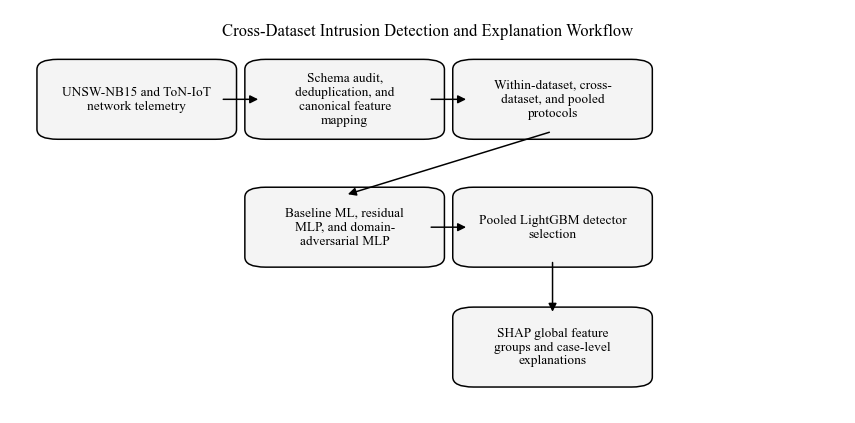

C:\Users\amala\AppData\Local\Temp\ipykernel_32804\3745063966.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("Greys").copy()


Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\f1_protocol_heatmap.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\f1_protocol_heatmap.png


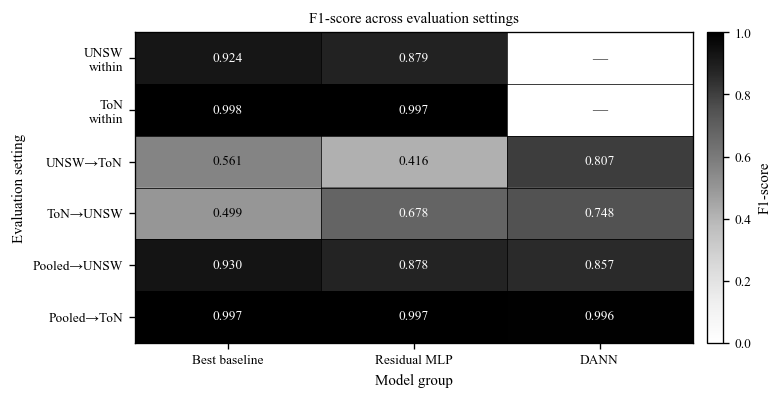

Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.png


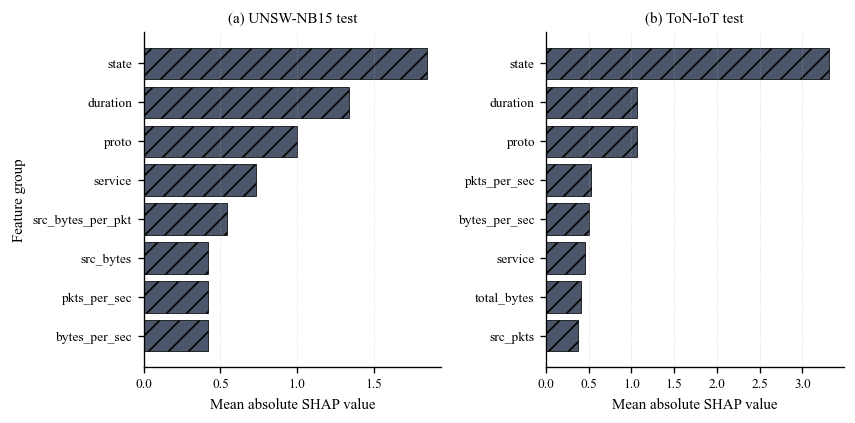


Final figure files
System workflow: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.pdf
F1 heatmap:      F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\f1_protocol_heatmap.pdf
Combined SHAP:   F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.pdf


In [5]:
from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "output"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
FIG_DIR = OUT_DIR / "figures"
FINAL_FIG_DIR = FIG_DIR / "final"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})


def save_figure(fig, name):
    pdf_path = FINAL_FIG_DIR / f"{name}.pdf"
    png_path = FINAL_FIG_DIR / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

    return pdf_path, png_path


# ---------------------------------------------------------------------
# Figure 1: System workflow
# ---------------------------------------------------------------------
def draw_box(ax, xy, width, height, text, facecolor="#F4F4F4"):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=0.9,
        edgecolor="black",
        facecolor=facecolor,
    )
    ax.add_patch(box)

    wrapped = "\n".join(textwrap.wrap(text, width=24))
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        wrapped,
        ha="center",
        va="center",
        fontsize=8,
    )


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=10,
        linewidth=0.9,
        color="black",
    )
    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

box_w = 0.20
box_h = 0.16

boxes = {
    "data": (0.05, 0.70, "UNSW-NB15 and ToN-IoT network telemetry"),
    "mapping": (0.30, 0.70, "Schema audit, deduplication, and canonical feature mapping"),
    "protocols": (0.55, 0.70, "Within-dataset, cross-dataset, and pooled protocols"),
    "models": (0.30, 0.38, "Baseline ML, residual MLP, and domain-adversarial MLP"),
    "selection": (0.55, 0.38, "Pooled LightGBM detector selection"),
    "explain": (0.55, 0.08, "SHAP global feature groups and case-level explanations"),
}

for key, (x, y, label) in boxes.items():
    draw_box(ax, (x, y), box_w, box_h, label)

draw_arrow(ax, (0.25, 0.78), (0.30, 0.78))
draw_arrow(ax, (0.50, 0.78), (0.55, 0.78))
draw_arrow(ax, (0.65, 0.70), (0.40, 0.54))
draw_arrow(ax, (0.50, 0.46), (0.55, 0.46))
draw_arrow(ax, (0.65, 0.38), (0.65, 0.24))

ax.text(
    0.5,
    0.97,
    "Cross-Dataset Intrusion Detection and Explanation Workflow",
    ha="center",
    va="top",
    fontsize=10,
)

plt.tight_layout()
workflow_pdf, workflow_png = save_figure(fig, "system_workflow")
plt.show()


# ---------------------------------------------------------------------
# Figure 2: F1-score heatmap
# ---------------------------------------------------------------------
model_results = pd.read_csv(TABLE_DIR / "summary" / "model_results_summary.csv")

setting_order = [
    "E1_UNSW_within",
    "E2_ToN_within",
    "E3_UNSW_to_ToN",
    "E4_ToN_to_UNSW",
    "E5_Pooled_to_UNSW",
    "E5_Pooled_to_ToN",
]

setting_labels = {
    "E1_UNSW_within": "UNSW\nwithin",
    "E2_ToN_within": "ToN\nwithin",
    "E3_UNSW_to_ToN": "UNSW→ToN",
    "E4_ToN_to_UNSW": "ToN→UNSW",
    "E5_Pooled_to_UNSW": "Pooled→UNSW",
    "E5_Pooled_to_ToN": "Pooled→ToN",
}

model_group_order = ["Best baseline", "Residual MLP", "DANN"]

heatmap_df = (
    model_results
    .pivot_table(
        index="setting",
        columns="model_group",
        values="f1",
        aggfunc="first",
    )
    .reindex(index=setting_order, columns=model_group_order)
)

heatmap_values = heatmap_df.values.astype(float)
masked_values = np.ma.masked_invalid(heatmap_values)

fig, ax = plt.subplots(figsize=(6.6, 3.4))

cmap = mpl.cm.get_cmap("Greys").copy()
cmap.set_bad(color="white")

im = ax.imshow(masked_values, cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")

ax.set_xticks(np.arange(len(model_group_order)))
ax.set_xticklabels(model_group_order)

ax.set_yticks(np.arange(len(setting_order)))
ax.set_yticklabels([setting_labels[s] for s in setting_order])

ax.set_xlabel("Model group")
ax.set_ylabel("Evaluation setting")
ax.set_title("F1-score across evaluation settings")

for i in range(heatmap_values.shape[0]):
    for j in range(heatmap_values.shape[1]):
        value = heatmap_values[i, j]

        if np.isnan(value):
            ax.text(j, i, "—", ha="center", va="center", fontsize=9)
        else:
            text_color = "white" if value > 0.65 else "black"
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8, color=text_color)

ax.set_xticks(np.arange(-0.5, len(model_group_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(setting_order), 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.45)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("F1-score")

plt.tight_layout()
heatmap_pdf, heatmap_png = save_figure(fig, "f1_protocol_heatmap")
plt.show()


# ---------------------------------------------------------------------
# Figure 3: Combined SHAP feature groups
# ---------------------------------------------------------------------
top_shap = pd.read_csv(TABLE_DIR / "summary" / "top_shap_summary.csv")

protocol_order = ["E5_Pooled_to_UNSW", "E5_Pooled_to_ToN"]
protocol_titles = {
    "E5_Pooled_to_UNSW": "(a) UNSW-NB15 test",
    "E5_Pooled_to_ToN": "(b) ToN-IoT test",
}

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6), sharey=False)

for ax, protocol in zip(axes, protocol_order):
    plot_df = top_shap[top_shap["protocol"] == protocol].copy()
    plot_df = plot_df.head(8)
    plot_df = plot_df.sort_values("mean_abs_shap", ascending=True)

    ax.barh(
        plot_df["feature_group"],
        plot_df["mean_abs_shap"],
        color="#4C566A",
        edgecolor="black",
        linewidth=0.45,
        hatch="//",
    )

    ax.set_title(protocol_titles[protocol])
    ax.set_xlabel("Mean absolute SHAP value")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Feature group")

plt.tight_layout()
shap_pdf, shap_png = save_figure(fig, "shap_combined")
plt.show()


print("\nFinal figure files")
print(f"System workflow: {workflow_pdf}")
print(f"F1 heatmap:      {heatmap_pdf}")
print(f"Combined SHAP:   {shap_pdf}")

Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.png


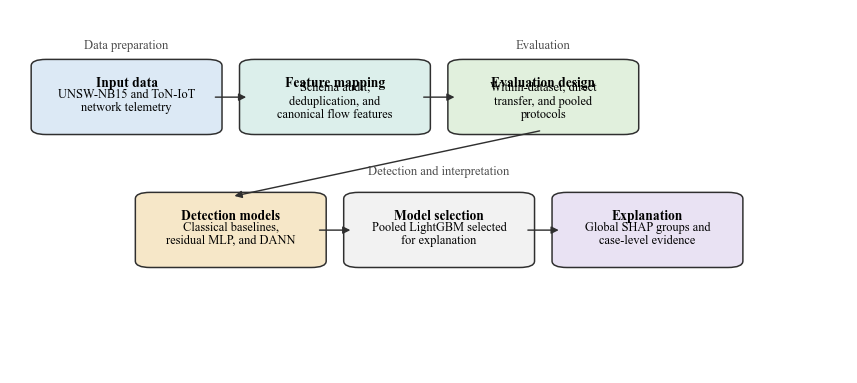

Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.png


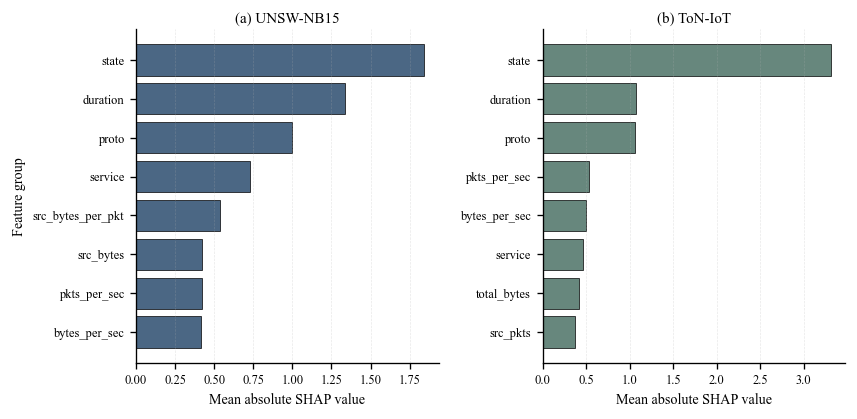


Final manuscript figures
System workflow: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\system_workflow.pdf
Combined SHAP:   F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_combined.pdf


In [6]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


FINAL_FIG_DIR = FIG_DIR / "final"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Figure style
# ---------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})


# Muted color palette
COLORS = {
    "navy": "#26364A",
    "blue": "#DCE9F5",
    "teal": "#DCEFEB",
    "green": "#E1F0DD",
    "amber": "#F6E7C8",
    "purple": "#E9E2F3",
    "gray": "#F2F2F2",
    "dark_gray": "#4A4A4A",
    "line": "#2F2F2F",
}


def save_figure(fig, name):
    pdf_path = FINAL_FIG_DIR / f"{name}.pdf"
    png_path = FINAL_FIG_DIR / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

    return pdf_path, png_path


# ---------------------------------------------------------------------
# Figure 1: System workflow
# ---------------------------------------------------------------------
def add_box(ax, x, y, w, h, title, body, color):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=0.9,
        edgecolor=COLORS["line"],
        facecolor=color,
    )
    ax.add_patch(box)

    ax.text(
        x + w / 2,
        y + h - 0.035,
        title,
        ha="center",
        va="top",
        fontsize=8.2,
        fontweight="bold",
        color="black",
    )

    wrapped = "\n".join(textwrap.wrap(body, width=24))
    ax.text(
        x + w / 2,
        y + h / 2 - 0.012,
        wrapped,
        ha="center",
        va="center",
        fontsize=7.4,
        color="black",
        linespacing=1.15,
    )


def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=9,
        linewidth=0.85,
        color=COLORS["line"],
        shrinkA=2,
        shrinkB=2,
    )
    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(7.2, 3.25))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

box_w = 0.205
box_h = 0.185

# Top row
add_box(
    ax,
    0.035,
    0.67,
    box_w,
    box_h,
    "Input data",
    "UNSW-NB15 and ToN-IoT network telemetry",
    COLORS["blue"],
)

add_box(
    ax,
    0.285,
    0.67,
    box_w,
    box_h,
    "Feature mapping",
    "Schema audit, deduplication, and canonical flow features",
    COLORS["teal"],
)

add_box(
    ax,
    0.535,
    0.67,
    box_w,
    box_h,
    "Evaluation design",
    "Within-dataset, direct transfer, and pooled protocols",
    COLORS["green"],
)

# Bottom row
add_box(
    ax,
    0.160,
    0.30,
    box_w,
    box_h,
    "Detection models",
    "Classical baselines, residual MLP, and DANN",
    COLORS["amber"],
)

add_box(
    ax,
    0.410,
    0.30,
    box_w,
    box_h,
    "Model selection",
    "Pooled LightGBM selected for explanation",
    COLORS["gray"],
)

add_box(
    ax,
    0.660,
    0.30,
    box_w,
    box_h,
    "Explanation",
    "Global SHAP groups and case-level evidence",
    COLORS["purple"],
)

# Arrows
add_arrow(ax, (0.240, 0.762), (0.285, 0.762))
add_arrow(ax, (0.490, 0.762), (0.535, 0.762))
add_arrow(ax, (0.637, 0.670), (0.263, 0.485))
add_arrow(ax, (0.365, 0.392), (0.410, 0.392))
add_arrow(ax, (0.615, 0.392), (0.660, 0.392))

# Light section labels
ax.text(
    0.137,
    0.905,
    "Data preparation",
    ha="center",
    va="center",
    fontsize=7.6,
    color=COLORS["dark_gray"],
)

ax.text(
    0.637,
    0.905,
    "Evaluation",
    ha="center",
    va="center",
    fontsize=7.6,
    color=COLORS["dark_gray"],
)

ax.text(
    0.512,
    0.555,
    "Detection and interpretation",
    ha="center",
    va="center",
    fontsize=7.6,
    color=COLORS["dark_gray"],
)

plt.tight_layout()
system_pdf, system_png = save_figure(fig, "system_workflow")
plt.show()


# ---------------------------------------------------------------------
# Figure 2: Combined SHAP feature groups
# ---------------------------------------------------------------------
top_shap = pd.read_csv(TABLE_DIR / "summary" / "top_shap_summary.csv")

protocol_order = ["E5_Pooled_to_UNSW", "E5_Pooled_to_ToN"]

protocol_titles = {
    "E5_Pooled_to_UNSW": "(a) UNSW-NB15",
    "E5_Pooled_to_ToN": "(b) ToN-IoT",
}

protocol_colors = {
    "E5_Pooled_to_UNSW": "#3B5A7A",
    "E5_Pooled_to_ToN": "#5A7D72",
}

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.55), sharey=False)

for ax, protocol in zip(axes, protocol_order):
    plot_df = top_shap[top_shap["protocol"] == protocol].copy()
    plot_df = plot_df.head(8)
    plot_df = plot_df.sort_values("mean_abs_shap", ascending=True)

    ax.barh(
        plot_df["feature_group"],
        plot_df["mean_abs_shap"],
        color=protocol_colors[protocol],
        edgecolor="black",
        linewidth=0.45,
        alpha=0.92,
    )

    ax.set_title(protocol_titles[protocol], pad=4)
    ax.set_xlabel("Mean absolute SHAP value")
    ax.grid(axis="x", linestyle="--", alpha=0.30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.8)

axes[0].set_ylabel("Feature group")

plt.tight_layout(w_pad=1.5)
shap_pdf, shap_png = save_figure(fig, "shap_combined")
plt.show()


print("\nFinal manuscript figures")
print(f"System workflow: {system_pdf}")
print(f"Combined SHAP:   {shap_pdf}")

Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\cross_dataset_evaluation_matrix.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\cross_dataset_evaluation_matrix.png


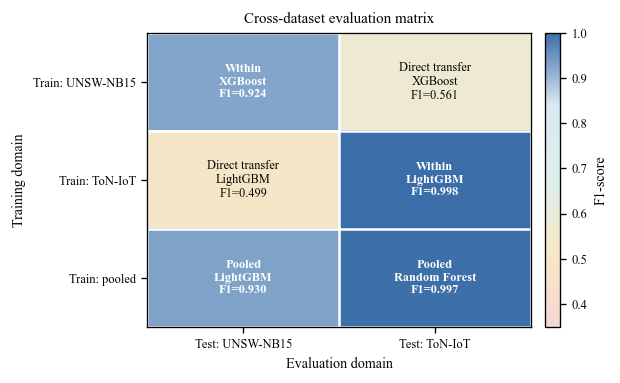

Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\domain_shift_adaptation.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\domain_shift_adaptation.png


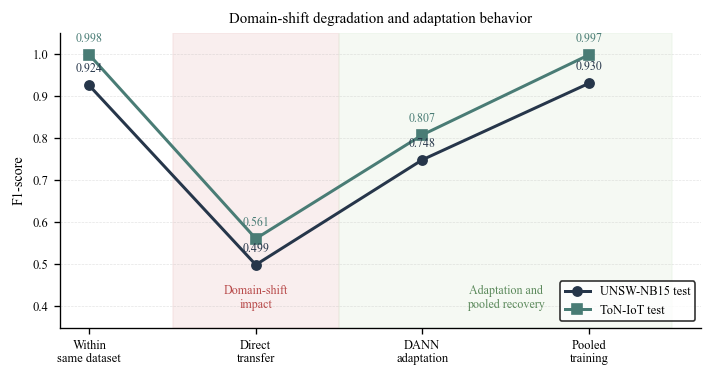

C:\Users\amala\AppData\Local\Temp\ipykernel_9540\2001164562.py:432: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_global_local_evidence.pdf
Saved: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_global_local_evidence.png


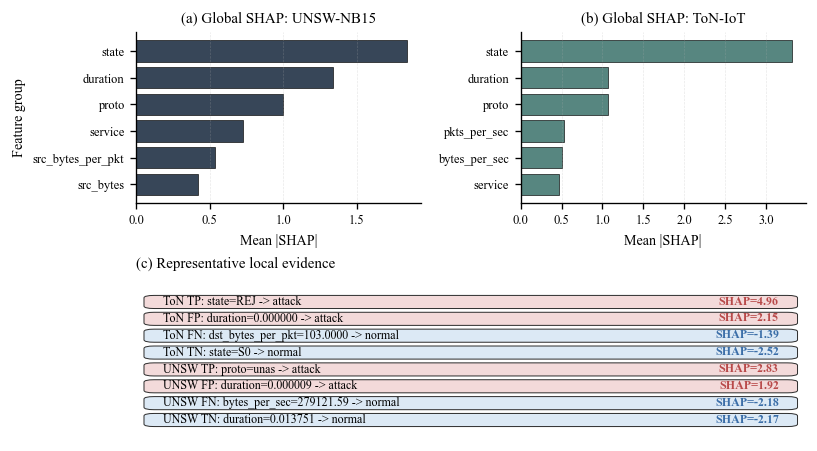


Final additional manuscript figures
Cross-dataset evaluation matrix: F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\cross_dataset_evaluation_matrix.pdf
Domain-shift adaptation:        F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\domain_shift_adaptation.pdf
SHAP global/local evidence:     F:\MBZUAI UAE\16-Conference\2-Wireless-IoT-IDS-WiMob26\Wireless-IoT-IDS\output\figures\final\shap_global_local_evidence.pdf


In [3]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR / "output"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
FIG_DIR = OUT_DIR / "figures"
FINAL_FIG_DIR = FIG_DIR / "final"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8.5,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})


COLORS = {
    "navy": "#26364A",
    "blue": "#3B6EA8",
    "light_blue": "#DCE9F5",
    "teal": "#497C75",
    "light_teal": "#DCEFEB",
    "green": "#5C8A5C",
    "light_green": "#E3F0DF",
    "amber": "#D99A1E",
    "light_amber": "#F7E8C7",
    "purple": "#6E4C8B",
    "light_purple": "#E9E2F3",
    "red": "#B84A4A",
    "light_red": "#F3DADA",
    "gray": "#4A4A4A",
    "light_gray": "#F2F2F2",
    "line": "#2F2F2F",
}


def save_figure(fig, name):
    pdf_path = FINAL_FIG_DIR / f"{name}.pdf"
    png_path = FINAL_FIG_DIR / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

    return pdf_path, png_path


model_results = pd.read_csv(TABLE_DIR / "summary" / "model_results_summary.csv")
top_shap = pd.read_csv(TABLE_DIR / "summary" / "top_shap_summary.csv")
case_summary = pd.read_csv(TABLE_DIR / "summary" / "case_summary_compact.csv")


def get_metric_row(setting, model_group="Best baseline"):
    rows = model_results[
        (model_results["setting"] == setting)
        & (model_results["model_group"] == model_group)
    ]

    if len(rows) == 0:
        raise ValueError(f"No result for setting={setting}, model_group={model_group}")

    return rows.iloc[0]


# ---------------------------------------------------------------------
# Figure 2: Cross-dataset evaluation matrix
# ---------------------------------------------------------------------
matrix_cells = [
    [
        {
            "setting": "E1_UNSW_within",
            "train": "UNSW-NB15",
            "test": "UNSW-NB15",
            "type": "Within",
            "row": get_metric_row("E1_UNSW_within"),
        },
        {
            "setting": "E3_UNSW_to_ToN",
            "train": "UNSW-NB15",
            "test": "ToN-IoT",
            "type": "Direct transfer",
            "row": get_metric_row("E3_UNSW_to_ToN"),
        },
    ],
    [
        {
            "setting": "E4_ToN_to_UNSW",
            "train": "ToN-IoT",
            "test": "UNSW-NB15",
            "type": "Direct transfer",
            "row": get_metric_row("E4_ToN_to_UNSW"),
        },
        {
            "setting": "E2_ToN_within",
            "train": "ToN-IoT",
            "test": "ToN-IoT",
            "type": "Within",
            "row": get_metric_row("E2_ToN_within"),
        },
    ],
    [
        {
            "setting": "E5_Pooled_to_UNSW",
            "train": "Pooled",
            "test": "UNSW-NB15",
            "type": "Pooled",
            "row": get_metric_row("E5_Pooled_to_UNSW"),
        },
        {
            "setting": "E5_Pooled_to_ToN",
            "train": "Pooled",
            "test": "ToN-IoT",
            "type": "Pooled",
            "row": get_metric_row("E5_Pooled_to_ToN"),
        },
    ],
]

f1_matrix = np.array([
    [matrix_cells[i][j]["row"]["f1"] for j in range(2)]
    for i in range(3)
], dtype=float)

row_labels = ["Train: UNSW-NB15", "Train: ToN-IoT", "Train: pooled"]
col_labels = ["Test: UNSW-NB15", "Test: ToN-IoT"]

matrix_cmap = LinearSegmentedColormap.from_list(
    "matrix_cmap",
    ["#F6D6D6", "#F7E8C7", "#DCEFEB", "#DCE9F5", "#3B6EA8"]
)

fig, ax = plt.subplots(figsize=(5.2, 3.25))

im = ax.imshow(f1_matrix, cmap=matrix_cmap, vmin=0.35, vmax=1.0, aspect="auto")

ax.set_xticks(np.arange(2))
ax.set_xticklabels(col_labels)
ax.set_yticks(np.arange(3))
ax.set_yticklabels(row_labels)

ax.set_title("Cross-dataset evaluation matrix")
ax.set_xlabel("Evaluation domain")
ax.set_ylabel("Training domain")

for i in range(3):
    for j in range(2):
        cell = matrix_cells[i][j]
        row = cell["row"]

        text_color = "white" if row["f1"] >= 0.92 else "black"

        ax.text(
            j,
            i,
            f"{cell['type']}\n{row['model']}\nF1={row['f1']:.3f}",
            ha="center",
            va="center",
            fontsize=7.4,
            color=text_color,
            fontweight="bold" if row["f1"] >= 0.92 else "normal",
        )

ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.035)
cbar.set_label("F1-score")

plt.tight_layout()
matrix_pdf, matrix_png = save_figure(fig, "cross_dataset_evaluation_matrix")
plt.show()


# ---------------------------------------------------------------------
# Figure 3: Domain-shift degradation and adaptation
# ---------------------------------------------------------------------
stages = [
    "Within\nsame dataset",
    "Direct\ntransfer",
    "DANN\nadaptation",
    "Pooled\ntraining",
]

x = np.arange(len(stages))

unsw_values = [
    get_metric_row("E1_UNSW_within", "Best baseline")["f1"],
    get_metric_row("E4_ToN_to_UNSW", "Best baseline")["f1"],
    get_metric_row("E4_ToN_to_UNSW", "DANN")["f1"],
    get_metric_row("E5_Pooled_to_UNSW", "Best baseline")["f1"],
]

ton_values = [
    get_metric_row("E2_ToN_within", "Best baseline")["f1"],
    get_metric_row("E3_UNSW_to_ToN", "Best baseline")["f1"],
    get_metric_row("E3_UNSW_to_ToN", "DANN")["f1"],
    get_metric_row("E5_Pooled_to_ToN", "Best baseline")["f1"],
]

fig, ax = plt.subplots(figsize=(6.0, 3.2))

ax.plot(
    x,
    unsw_values,
    marker="o",
    markersize=5.5,
    linewidth=1.8,
    color=COLORS["navy"],
    label="UNSW-NB15 test",
)

ax.plot(
    x,
    ton_values,
    marker="s",
    markersize=5.5,
    linewidth=1.8,
    color=COLORS["teal"],
    label="ToN-IoT test",
)

for values, color in [(unsw_values, COLORS["navy"]), (ton_values, COLORS["teal"])]:
    for xi, value in zip(x, values):
        ax.text(
            xi,
            value + 0.025,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=7.2,
            color=color,
        )

# Highlight the direct-transfer degradation region
ax.axvspan(0.5, 1.5, color=COLORS["light_red"], alpha=0.45, zorder=0)
ax.axvspan(1.5, 3.5, color=COLORS["light_green"], alpha=0.35, zorder=0)

ax.text(
    1.0,
    0.39,
    "Domain-shift\nimpact",
    ha="center",
    va="bottom",
    fontsize=7.2,
    color=COLORS["red"],
)

ax.text(
    2.5,
    0.39,
    "Adaptation and\npooled recovery",
    ha="center",
    va="bottom",
    fontsize=7.2,
    color=COLORS["green"],
)

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel("F1-score")
ax.set_ylim(0.35, 1.05)
ax.set_title("Domain-shift degradation and adaptation behavior")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True, edgecolor="black")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
shift_pdf, shift_png = save_figure(fig, "domain_shift_adaptation")
plt.show()


# ---------------------------------------------------------------------
# Figure 4: SHAP global and local evidence groups
# ---------------------------------------------------------------------
global_unsw = (
    top_shap[top_shap["protocol"] == "E5_Pooled_to_UNSW"]
    .head(6)
    .copy()
    .sort_values("mean_abs_shap", ascending=True)
)

global_ton = (
    top_shap[top_shap["protocol"] == "E5_Pooled_to_ToN"]
    .head(6)
    .copy()
    .sort_values("mean_abs_shap", ascending=True)
)

case_display = case_summary.copy()
case_display["case_short"] = case_display["case_type"].map({
    "true_positive": "TP",
    "false_positive": "FP",
    "false_negative": "FN",
    "true_negative": "TN",
})

case_display["domain"] = case_display["dataset"].replace({
    "UNSW-NB15": "UNSW",
    "ToN-IoT": "ToN",
})

case_display["local_text"] = (
    case_display["domain"]
    + " "
    + case_display["case_short"]
    + ": "
    + case_display["top_evidence"].astype(str)
    + " -> "
    + case_display["direction"].astype(str)
)

case_display = case_display[
    ["local_text", "top_shap", "direction"]
].copy()

# Keep the figure compact
case_display = case_display.head(8)

fig = plt.figure(figsize=(7.2, 4.4))
gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1.05, 1.05],
    height_ratios=[1.0, 0.95],
    hspace=0.45,
    wspace=0.35,
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

ax1.barh(
    global_unsw["feature_group"],
    global_unsw["mean_abs_shap"],
    color=COLORS["navy"],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.92,
)

ax1.set_title("(a) Global SHAP: UNSW-NB15")
ax1.set_xlabel("Mean |SHAP|")
ax1.set_ylabel("Feature group")
ax1.grid(axis="x", linestyle="--", alpha=0.30)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.barh(
    global_ton["feature_group"],
    global_ton["mean_abs_shap"],
    color=COLORS["teal"],
    edgecolor="black",
    linewidth=0.4,
    alpha=0.92,
)

ax2.set_title("(b) Global SHAP: ToN-IoT")
ax2.set_xlabel("Mean |SHAP|")
ax2.grid(axis="x", linestyle="--", alpha=0.30)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax3.axis("off")
ax3.set_title("(c) Representative local evidence", loc="left", pad=6)

y_positions = np.linspace(0.85, 0.12, len(case_display))

for y, (_, row) in zip(y_positions, case_display.iterrows()):
    direction_color = COLORS["red"] if row["direction"] == "attack" else COLORS["blue"]

    box = FancyBboxPatch(
        (0.02, y - 0.035),
        0.96,
        0.065,
        boxstyle="round,pad=0.008,rounding_size=0.015",
        linewidth=0.6,
        edgecolor=COLORS["line"],
        facecolor=COLORS["light_red"] if row["direction"] == "attack" else COLORS["light_blue"],
        transform=ax3.transAxes,
    )
    ax3.add_patch(box)

    ax3.text(
        0.04,
        y,
        row["local_text"],
        ha="left",
        va="center",
        fontsize=7.2,
        transform=ax3.transAxes,
        color="black",
    )

    ax3.text(
        0.96,
        y,
        f"SHAP={row['top_shap']:.2f}",
        ha="right",
        va="center",
        fontsize=7.2,
        transform=ax3.transAxes,
        color=direction_color,
        fontweight="bold",
    )

plt.tight_layout()
shap_evidence_pdf, shap_evidence_png = save_figure(fig, "shap_global_local_evidence")
plt.show()


print("\nFinal additional manuscript figures")
print(f"Cross-dataset evaluation matrix: {matrix_pdf}")
print(f"Domain-shift adaptation:        {shift_pdf}")
print(f"SHAP global/local evidence:     {shap_evidence_pdf}")